In [1]:
!pip install transformers torch

# TRANSFORMERS

## Vaswani et al. (2017) - Atention is all you need


O artigo "Attention is All You Need" introduz os Transformers, uma arquitetura inovadora para lidar com problemas sequenciais em aprendizado de máquina. Ele aborda limitações das abordagens baseadas em RNNs e LSTMs e propõe uma solução eficiente: o uso exclusivo do mecanismo de atenção.

**Problema principal abordado:** paralelização de dependências de longa distância.

### Transformers

O Transformer é uma arquitetura de rede neural inovadora proposta no artigo "Attention is All You Need". Ele foi projetado para resolver problemas de aprendizado em sequências, como tradução automática, geração de texto e tarefas relacionadas a linguagem e séries temporais.

#### O que o Transformer trouxe de novo?
* Quebra com as abordagens tradicionais: Antes, modelos como RNNs, LSTMs e GRUs eram as principais escolhas para dados sequenciais. Esses modelos processavam sequências palavra por palavra, de forma serial, o que era lento e limitava o aprendizado de dependências de longo alcance.
* Paralelismo:
O Transformer processa toda a sequência de uma vez, graças ao mecanismo de atenção. Isso torna o treinamento muito mais rápido e escalável.
* Foco no Mecanismo de Atenção: Em vez de depender de recorrência (como RNNs) ou convoluções (como CNNs), o Transformer usa atenção para capturar relações entre tokens.

#### Impacto dessa inovação:
* Melhor desempenho em tarefas de NLP, superando abordagens anteriores.
Base para modelos como BERT, GPT e T5.
* Aplicação além de NLP, como visão computacional (Vision Transformers).

### Self-Attention - Atenção auto-regressiva

 Permite que cada palavra (ou token) de uma sequência "preste atenção" em todas as outras palavras da sequência.

#### Como funciona o Self-Attention?
1. Criação de Vetores (Query, Key, Value):
* Cada token da entrada é transformado em três vetores:
  * Query (Q): Representa "o que essa palavra está buscando".
  * Key (K): Representa "o que essa palavra oferece".
  * Value (V): Representa "a informação associada a essa palavra".
2. Cálculo da Similaridade:
* Para cada par de palavras, calcula-se a similaridade entre o Query de uma palavra e o Key das outras.
3. Distribuição de Atenção:
* Os pesos calculados são normalizados com uma softmax para criar uma distribuição de atenção.
4. Soma Ponderada:
* Os pesos de atenção são usados para combinar os Values, criando uma representação contextual.

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

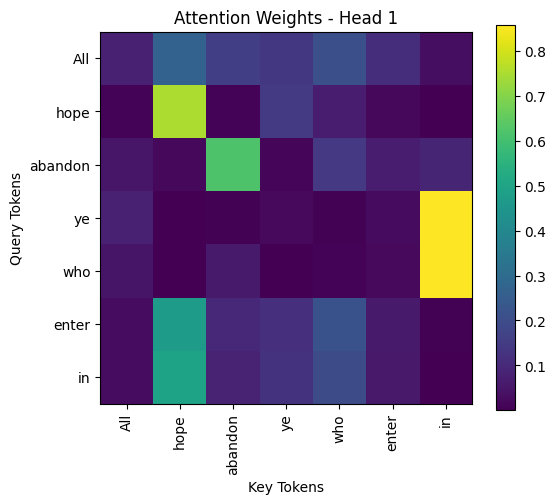

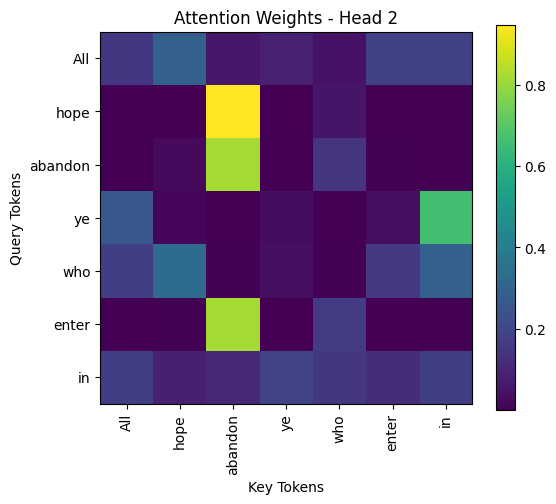

Tokens: ['All', 'hope', 'abandon', 'ye', 'who', 'enter', 'in']

Concatenated Output (Multi-Head Attention):
tensor([[ 0.1161,  1.6044,  0.5781,  1.1270],
        [ 0.2004,  3.5199, -1.1682, -0.3029],
        [-1.0772,  0.0110,  0.3753,  1.6178],
        [ 0.3845,  1.5147, -0.4229,  0.5920],
        [-5.4288, -0.9077, -5.0046, -0.6675],
        [ 0.2764, -0.1916, -0.0484,  0.5113],
        [-5.0681, -0.6721, -0.6155,  0.5031]])


In [3]:
# Simplificado: sequência e embeddings menores
tokens = ["All", "hope", "abandon", "ye", "who", "enter", "in"]
sequence_length = len(tokens)
embed_size = 4  # Dimensão reduzida para eficiência
num_heads = 2

# Embeddings simulados
embeddings = torch.randn(sequence_length, embed_size)

# Pesos para multi-head attention (2 cabeças)
W_q = torch.randn(num_heads, embed_size, embed_size // num_heads)
W_k = torch.randn(num_heads, embed_size, embed_size // num_heads)
W_v = torch.randn(num_heads, embed_size, embed_size // num_heads)

# Calculando Q, K, V para cada cabeça
Q = torch.einsum("ij,hjk->hik", embeddings, W_q)
K = torch.einsum("ij,hjk->hik", embeddings, W_k)
V = torch.einsum("ij,hjk->hik", embeddings, W_v)

# Atenção escalada para cada cabeça
scores = torch.einsum("hik,hjk->hij", Q, K)
scaled_scores = scores / torch.sqrt(torch.tensor(embed_size // num_heads, dtype=torch.float32))
attention_weights = F.softmax(scaled_scores, dim=-1)

# Aplicação de atenção nos valores
outputs = torch.einsum("hij,hjk->hik", attention_weights, V)
concatenated_output = outputs.view(sequence_length, -1)  # Concatenar saídas de todas as cabeças

# Visualizando os pesos de atenção para cada cabeça
for head in range(num_heads):
    plt.figure(figsize=(6, 5))
    plt.imshow(attention_weights[head].detach().numpy(), cmap="viridis")
    plt.title(f"Attention Weights - Head {head + 1}")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.xticks(range(sequence_length), tokens, rotation=90)
    plt.yticks(range(sequence_length), tokens)
    plt.colorbar()
    plt.show()

# Exibir o resultado concatenado
print("Tokens:", tokens)
print("\nConcatenated Output (Multi-Head Attention):")
print(concatenated_output)


### Abandono de RNNs e CNNs

#### Limitações de RNNs

Recorrência (RNNs/LSTMs):
* Os modelos processavam sequências de forma serial, palavra por palavra, acumulando informações ao longo do tempo.
* Problema: Ineficiência (dificuldade em paralelizar o treinamento) e dificuldade em capturar dependências de longo alcance.

#### Limitações de CNNsConvolução (CNNs):

* As CNNs processam a entrada em blocos de palavras vizinhas (janelas locais).
* Problema: Embora eficientes, elas capturam relações locais e têm dificuldade em lidar com dependências distantes sem várias camadas.

#### Forma de operação dos Transformers

1. Eliminação de recorrência:
* O Transformer processa toda a sequência de uma vez, sem depender de uma ordem serial.
* Isso melhora a paralelização e reduz o tempo de treinamento.
2. Dispensa convoluções:
* Em vez de usar janelas locais, o mecanismo de atenção examina toda a sequência de entrada diretamente, capturando relações globais.
3. Eficiência Computacional:
* A ausência de recorrência permite que o Transformer use GPUs e TPUs de maneira mais eficiente.
4. Melhor aprendizado:
* Dependências de longo alcance são aprendidas mais facilmente, já que o modelo analisa a sequência como um todo.

In [8]:
from transformers import DistilBertTokenizer, DistilBertForQuestionAnswering, AutoTokenizer
import torch
import torch.nn as nn
import time

In [5]:
# Configurações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sequence_length = 512

# Texto longo (Contexto)
context = """
THROUGH me the way is to the city dolent;
Through me the way is to eternal dole;
Through me the way among the people lost.
Justice incited my sublime Creator;
Created me divine Omnipotence,
The highest Wisdom and the primal Love.
Before me there were no created things,
Only eterne, and I eternal last.
“All hope abandon, ye who enter in!”
These words in sombre colour I beheld
Written upon the summit of a gate;
Whence I: “Their sense is, Master, hard to me!”
And he to me, as one experienced:
“Here all suspicion needs must be abandoned,
All cowardice must needs be here extinct.
We to the place have come, where I have told thee
Thou shalt behold the people dolorous
Who have foregone the good of intellect.”
And after he had laid his hand on mine
With joyful mien, whence I was comforted,
He led me in among the secret things.
"""

In [6]:
# Pergunta
question = "What words were written upon a gate?"

In [9]:
# Tokenizador compartilhado com o experimento de QA
qa_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
)

config.json:   0%|          | 0.00/451 [00:00<?, ?B/s]

In [10]:
# Garante que sequence_length exista
try:
    sequence_length
except NameError:
    sequence_length = 128

# Tokenização do contexto e da pergunta
# Correção principal: usar qa_tokenizer(...) em vez de qa_tokenizer.encode_plus(...)
qa_inputs = qa_tokenizer(
    question,
    context,
    return_tensors="pt",
    max_length=sequence_length,
    truncation=True,
    padding="max_length"
)

inputs_ids = qa_inputs["input_ids"].to(device)
input_ids = inputs_ids  # alias para manter compatibilidade com código anterior
attention_mask = qa_inputs["attention_mask"].to(device)

class SimpleLSTMForQA(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size):
        super(SimpleLSTMForQA, self).__init__()
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc_start = nn.Linear(hidden_size, 1)
        self.fc_end = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        start_logits = self.fc_start(lstm_out).squeeze(-1)
        end_logits = self.fc_end(lstm_out).squeeze(-1)
        return start_logits, end_logits

hidden_size = 768
vocab_size = qa_tokenizer.vocab_size

lstm_model = SimpleLSTMForQA(
    vocab_size,
    hidden_size,
    hidden_size
).to(device)

# Responder à pergunta com LSTM
# Observação: este LSTM está inicializado aleatoriamente; ele roda como experimento comparativo,
# mas não deve ser interpretado como modelo treinado de QA.
with torch.no_grad():
    start = time.time()
    lstm_start_logits, lstm_end_logits = lstm_model(inputs_ids)
    lstm_time = time.time() - start

lstm_start_idx = torch.argmax(lstm_start_logits, dim=1).item()
lstm_end_idx = torch.argmax(lstm_end_logits, dim=1).item() + 1

# Evita fatias inválidas quando o modelo não treinado prevê fim antes do início
if lstm_end_idx <= lstm_start_idx:
    lstm_end_idx = min(lstm_start_idx + 1, inputs_ids.shape[1])

lstm_answer = qa_tokenizer.convert_tokens_to_string(
    qa_tokenizer.convert_ids_to_tokens(
        inputs_ids[0][lstm_start_idx:lstm_end_idx]
    )
)

print(f"LSTM Answer: '{lstm_answer}'")
print(f"LSTM Time: {lstm_time:.4f} seconds")

LSTM Answer: ','
LSTM Time: 0.2859 seconds


In [11]:
# Transformer (DistilBERT)
# Reaproveita a mesma tokenização do experimento LSTM para manter tudo consistente.

tokenizer = qa_tokenizer if "qa_tokenizer" in globals() else DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
)
transformer_model = DistilBertForQuestionAnswering.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
).to(device)

if "qa_inputs" in globals():
    inputs = qa_inputs
else:
    inputs = tokenizer.encode_plus(
        question,
        context,
        return_tensors="pt",
        max_length=sequence_length,
        truncation=True,
    )

inputs_ids = inputs["input_ids"].to(device)
input_ids = inputs_ids  # alias para compatibilidade com a API e com células antigas
attention_mask = inputs["attention_mask"].to(device)

# Responder à pergunta com Transformer
with torch.no_grad():
    start = time.time()
    outputs = transformer_model(input_ids=input_ids, attention_mask=attention_mask)
    start_scores = outputs.start_logits
    end_scores = outputs.end_logits
    transformer_time = time.time() - start

# Identificar a resposta
start_idx = torch.argmax(start_scores, dim=1).item()
end_idx = torch.argmax(end_scores, dim=1).item() + 1

if end_idx <= start_idx:
    end_idx = min(start_idx + 1, input_ids.shape[1])

transformer_answer = tokenizer.convert_tokens_to_string(
    tokenizer.convert_ids_to_tokens(input_ids[0][start_idx:end_idx])
)

print(f"Transformer Answer: '{transformer_answer}'")
print(f"Transformer Time: {transformer_time:.4f} seconds")


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Transformer Answer: 'sombre colour'
Transformer Time: 0.6654 seconds


### Arquitetura Transformer

#### Noções gerais

##### Estrutura

Codificador-Decodificador:

* **Encoder:** Processa a entrada e cria uma representação abstrata (contexto).
* **Decoder:** Usa a representação do encoder para gerar a saída.

##### Componentes principais:

* **Mecanismo de Atenção:** Permite que o modelo "preste atenção" em partes importantes da entrada.
* **Self-Attention:** Atenção aplicada dentro da sequência (por exemplo, cada palavra prestando atenção nas outras).
* **Scaled Dot-Product Attention:** A fórmula chave para calcular atenção, balanceando foco em diferentes partes.
* **Camadas Feedforward:** Totalmente conectadas, aplicadas após o mecanismo de atenção.
* **Embeddings Posicionais:** Para incluir informações sobre a ordem das palavras, já que o Transformer não processa sequencialmente como RNNs.

#### Embeddings e Positional Encoding

* Embeddings: Cada palavra ou token é transformado em um vetor d-dimensional.
* Positional Encoding: Adicionado ao embedding para incorporar informações sobre a posição na sequência.
$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

**Onde:**
- \( pos \): Posição na sequência.
- \( i \): Índice da dimensão do vetor.
- \( d \): Dimensão do vetor de embeddings.
- \( PE \): Codificação posicional.

##### **Entendendo o Conceito**

Quando processamos uma sequência no Transformer, cada token (palavra ou subpalavra) é representado por um vetor de dimensão fixa $(d)$. Por exemplo, se $(d = 512)$, cada token é representado por um vetor de 512 números.

- Cada **posição** dentro desse vetor é identificada por um índice $(i)$, que varia de $(0)$ a $(d-1)$.
- Esse índice $(i)$ é usado nas fórmulas de codificação posicional para calcular um valor de $(\sin)$ ou $(\cos)$ específico para cada dimensão do vetor.

##### **Por que o Índice é Importante?**

O índice $(i)$ determina o comportamento das funções $(\sin)$ e $(\cos)$ em diferentes dimensões do vetor:

- Para **dimensões pares** $(2i)$, usamos $(\sin)$.
- Para **dimensões ímpares** $(2i+1)$, usamos $(\cos)$.

Essa diferenciação cria padrões únicos para cada dimensão, garantindo que a codificação posicional adicione informações sobre a posição $(pos)$ de maneira única e distribuída no vetor.

---

##### **Exemplo Prático**

Se o vetor de dimensão \( d = 6 \), temos os seguintes índices $(i)$:
- Dimensão 0: Índice $( i = 0 )$ (par, usa $(\sin)$).
- Dimensão 1: Índice $( i = 0 )$ (ímpar, usa $(\cos)$).
- Dimensão 2: Índice $( i = 1 )$ (par, usa $(\sin)$).
- Dimensão 3: Índice $( i = 1 )$ (ímpar, usa $(\cos)$).
- Dimensão 4: Índice $( i = 2 )$ (par, usa $(\sin)$).
- Dimensão 5: Índice $( i = 2 )$ (ímpar, usa $(\cos)$).

---

##### **Por que usar seno e cosseno na codificação posicional?**

A codificação posicional com funções trigonométricas ($sin$) e ($cos$) resolve um problema essencial: **como o Transformer entende a ordem dos tokens em uma sequência, se ele processa tudo de maneira paralela?**

---

###### **Motivação**
1. **Transformers não têm noção de sequência:**
   - Redes recorrentes (RNNs) processam os tokens um a um, carregando a ordem da sequência implicitamente no estado oculto.
   - No Transformer, os tokens são processados simultaneamente (em paralelo), então é necessário adicionar explicitamente informações sobre a posição dos tokens.

2. **Solução: Seno e Cosseno**
   - Funções trigonométricas ($sin$) e ($cos$) têm propriedades úteis:
     - **Suavidade**: Os valores mudam de maneira contínua conforme a posição aumenta.
     - **Periodicidade**: Permite que o modelo aprenda dependências tanto locais quanto globais.
     - **Unicidade**: A combinação de ($sin$) e ($cos$) em diferentes dimensões cria representações únicas para cada posição.

---

##### **Fórmulas de Codificação Posicional**

Para cada posição na sequência ($pos$) e dimensão ($i$) no vetor de embeddings ($d$):

1. Para dimensões pares ($2i$):
   $$
   PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
   $$

2. Para dimensões ímpares ($2i+1$):
   $$
   PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
   $$

---

##### **Propriedades Úteis**

1. **Dependências de curto e longo alcance:**
   - Dimensões com frequências mais altas (mudanças rápidas em seno/cosseno) representam relações próximas.
   - Dimensões com frequências mais baixas representam relações distantes.

2. **Semântica e Posição:**
   - A codificação posicional é somada ao vetor de embeddings de cada token.
   - Assim, o vetor final combina informações **semânticas** (provenientes do embedding) e **posicionais** (provenientes do seno/cosseno).

---

##### **Exemplo Visual**

Imagine uma sequência de palavras: $["João", "comprou", "carro"]$. Cada palavra tem um vetor de embedding de dimensão $d = 4$:
$$
\text{"João"} \rightarrow [0.5, 1.2, -0.3, 0.8] \\
\text{"comprou"} \rightarrow [-0.1, 0.9, 0.7, -0.4] \\
\text{"carro"} \rightarrow [1.1, -0.6, 0.3, 0.5]
$$

Agora, adicionamos as codificações posicionais:

1. Para $pos = 0$:
   $$
   PE(0) = [\sin(0), \cos(0), \sin(0), \cos(0)] = [0, 1, 0, 1]
   $$

2. Para $pos = 1$:
   $$
   PE(1) = [\sin(1), \cos(1), \sin\left(\frac{1}{10000}\right), \cos\left(\frac{1}{10000}\right)]
   $$

3. Para $pos = 2$:
   $$
   PE(2) = [\sin(2), \cos(2), \sin\left(\frac{2}{10000}\right), \cos\left(\frac{2}{10000}\right)]
   $$

O vetor final para "João" será:

$$
\text{"João"}_{\text{final}} = \text{"João"}_{\text{embedding}} + PE(0) = [0.5, 1.2, -0.3, 0.8] + [0, 1, 0, 1] = [0.5, 2.2, -0.3, 1.8]
$$

---

##### **Por que seno e cosseno são melhores que aprender embeddings de posição?**

1. **Generalização para sequências maiores:**
   - A periodicidade das funções trigonométricas permite que o modelo generalize para comprimentos de sequência maiores do que os vistos durante o treinamento.

2. **Eficiência computacional:**
   - Codificações posicionais baseadas em ($sin$) e ($cos$) podem ser calculadas sem parâmetros adicionais, reduzindo a complexidade do modelo.

3. **Preservação de relações posicionais:**
   - A diferença entre dois vetores codificados posicionalmente (subtração) preserva relações espaciais, o que é útil no mecanismo de atenção.

---

##### **Relação com o Cálculo de Similaridade no Transformer**

O Transformer calcula a atenção entre tokens usando **produto escalar** no mecanismo de atenção:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- Aqui, $Q$ (query), $K$ (key) e $V$ (value) são derivados dos embeddings de entrada, que já incluem as codificações posicionais.
- O produto escalar entre $Q$ e $K$ mede a similaridade entre os tokens, levando em conta a informação posicional.

---

##### **Resumo**

O uso de ($sin$) e ($cos$) nas codificações posicionais permite ao Transformer:
1. Incorporar informações de posição explicitamente.
2. Aprender relações locais e globais na sequência.
3. Manter eficiência computacional enquanto generaliza para sequências maiores.




In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


Word Embeddings (Vetores densos de cada palavra):
tensor([[-0.8826,  0.1352,  0.6236, -0.8858, -0.1766, -0.3985],
        [ 0.2384,  0.1006,  0.3496, -1.9239, -0.5041,  1.0695],
        [ 2.0568, -1.8055,  1.1722, -0.6326,  1.4274, -0.5353],
        [ 0.1268,  2.5100,  0.6434,  0.1046,  0.0473, -0.4925],
        [ 0.6458,  0.9625, -1.2643, -0.6809,  1.1278,  1.4477],
        [ 1.0944, -2.0027,  2.6920,  0.5143,  0.3651,  0.6320],
        [-0.0941, -1.4382, -0.7930,  0.5638, -0.0191,  2.0186]],
       grad_fn=<EmbeddingBackward0>)

Positional Encoding (Padrões senoide e cossenoide únicos para cada posição) 
 	 [seno, cosseno, seno, cosseno, seno, cosseno, seno]:
Senos notáveis. 
 0º = 0 
 30º = 0,5 
 45º = 0,7071 
 60º = 0,8660 
 90º - 1
Cossenos notáveis. 
 0º = 1 
 30º = 0,8660 
 45º = 0,7071 
 60º = 0,5 
 90º - 0
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957, 

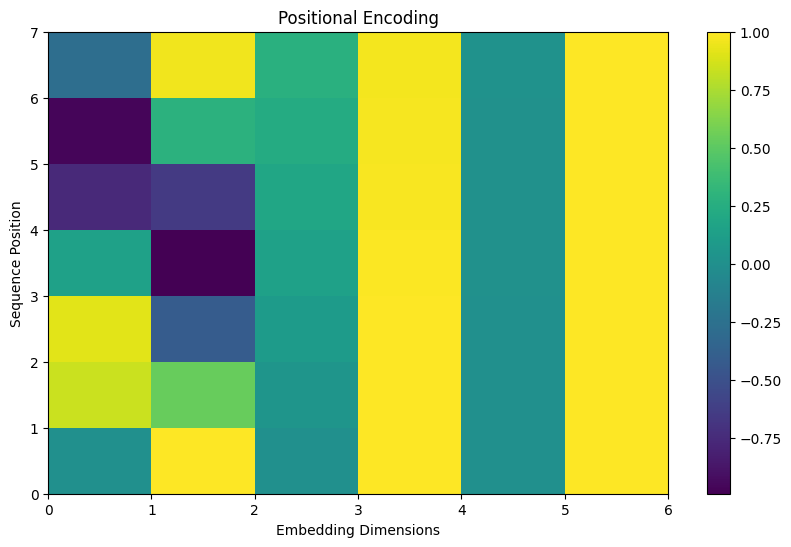

In [13]:
# Lista de palavras (sequência de entrada)
tokens = ["All", "hope", "abandon", "ye", "who", "enter", "in"]

# 1. Embeddings
vocab_size = 10  # Simulação de um vocabulário pequeno
embed_size = 6  # Dimensão do embedding
embedding_layer = nn.Embedding(vocab_size, embed_size)

# Mapear cada palavra para um índice (simulado)
word_to_idx = {word: i for i, word in enumerate(tokens)}
indices = torch.tensor([word_to_idx[word] for word in tokens])

# Gerar embeddings
embeddings = embedding_layer(indices)
print("Word Embeddings (Vetores densos de cada palavra):")
print(embeddings)

# 2. Positional Encoding
def positional_encoding(seq_len, embed_dim):
    pos = np.arange(seq_len)[:, np.newaxis]  # Posições (0, 1, ..., seq_len-1)
    i = np.arange(embed_dim)[np.newaxis, :]  # Dimensão do embedding (0, 1, ..., embed_dim-1)

    # Fórmula de Vaswani et al.
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / embed_dim)
    angle_rads = pos * angle_rates

    # Aplicar seno e cosseno
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  # Seno para índices pares
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  # Cosseno para índices ímpares
    return torch.tensor(angle_rads, dtype=torch.float32)

seq_len = len(tokens)
pos_encoding = positional_encoding(seq_len, embed_size)
print("\nPositional Encoding (Padrões senoide e cossenoide únicos para cada posição) \n \t [seno, cosseno, seno, cosseno, seno, cosseno, seno]:")
print("Senos notáveis. \n 0º = 0 \n 30º = 0,5 \n 45º = 0,7071 \n 60º = 0,8660 \n 90º - 1")
print("Cossenos notáveis. \n 0º = 1 \n 30º = 0,8660 \n 45º = 0,7071 \n 60º = 0,5 \n 90º - 0")
print(pos_encoding)

# 3. Combinação: Embeddings + Positional Encoding
final_representation = embeddings + pos_encoding
print("\nFinal Representation (A soma dos embeddings e do Positional Encoding):")
print(final_representation)

# 4. Visualização do Positional Encoding
plt.figure(figsize=(10, 6))
plt.pcolormesh(pos_encoding.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Sequence Position")
plt.show()


#### Self-Attention

- Calcula dependências entre todas as palavras de uma sequência.
- Três vetores principais:
  - **Query (Q)**: Qual token está "fazendo perguntas"?
  - **Key (K)**: Qual informação está disponível?
  - **Value (V)**: Qual resposta fornecer?
- Cálculo:
  $$
  \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
  $$

#### Multi-Head Attention

- Diversifica o foco do modelo com múltiplas "cabeças" de atenção paralelas.
  - Fórmula:
    
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O
$$


  - Onde cada cabeça é:
  
    $$
    \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
    $$

#### Feed-Forward

A Feedforward Network (FFN) é uma parte essencial de cada camada do Transformer (tanto no encoder quanto no decoder). Após a etapa de **Self-Attention**, cada vetor de token (que contém as informações semânticas e contextuais) é processado individualmente por essa rede.

* **Aplicada individualmente:** A FFN processa cada posição da sequência (ou seja, cada token) de forma independente. Não há troca de informações entre diferentes tokens nessa etapa.
* **Função principal:** Refinar a representação do token gerada pela etapa de atenção.

No Transformer, cada posição na sequência é representada por um vetor. Após a etapa de Self-Attention, cada vetor contém informações contextuais de todas as outras posições na sequência. A FFN:

* **Processa cada vetor separadamente:** Não altera o relacionamento entre os tokens, mas refina as informações contidas em cada vetor individualmente.
* **Paralelismo:** Como cada token é independente, a FFN pode ser aplicada em todos os tokens simultaneamente, aproveitando a capacidade das GPUs.

##### Feedforward Network no Transformer

A **Feedforward Network (FFN)** realiza duas transformações lineares em cada token individualmente:

---

###### Primeira Transformação Linear (Expansão da Dimensão):

$$ z = \text{ReLU}(xW_1 + b_1) $$

- \($ W_1 $): Matriz de pesos da primeira camada.
- \($b_1$): Vetor de bias da primeira camada.
- Dimensão da saída:
  $$
  d_{ff} = 4 \cdot d
  $$

---

###### Segunda Transformação Linear (Redução da Dimensão):

$$
y = zW_2 + b_2
$$

- \($W_2$): Matriz de pesos da segunda camada.
- \($b_2$): Vetor de bias da segunda camada.
- Retorna à dimensão original \($d$).

---

###### Por que essa estrutura é usada?

- **Expansão Temporária**: Permite ao modelo aprender padrões mais complexos em um espaço maior.
- **Redução Final**: Garante compatibilidade com outras partes do modelo e eficiência computacional.

---

###### Exemplo:

Se \($d = 64$) e \($d_{ff} = 256$):
- A entrada é um vetor de dimensão 64.
- A saída da primeira camada será um vetor de dimensão 256.
- A saída final retorna à dimensão 64.


#### Normalização e Drop-out

**Layer Normalization (Norm)** é uma técnica que normaliza os valores em cada **posição do vetor** (ou token) de forma independente, garantindo que todas as dimensões tenham uma média e variância consistentes.

##### **Por que usar Layer Normalization?**
1. **Estabilidade do Treinamento**:
   - Reduz a variabilidade dos valores intermediários em redes profundas, garantindo que os gradientes fluam bem.
2. **Aceleração da Convergência**:
   - Manter os valores normalizados acelera o aprendizado.
3. **Independência de Batch Size**:
   - Ao contrário de **Batch Normalization**, a LayerNorm calcula a média e variância **dentro de cada vetor**, permitindo seu uso em batch sizes pequenos.

##### **Fórmula Matemática**
Dado um vetor de entrada $x$ com $d$ dimensões:

$$
\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

**Onde:**
- $\mu$: Média dos valores em $x$.
- $\sigma^2$: Variância dos valores em $x$.
- $\epsilon$: Pequeno valor para evitar divisão por zero.
- $\gamma$: Fator de escala treinável.
- $\beta$: Fator de deslocamento treinável.

---

#### **Dropout**

**Dropout** é uma técnica de regularização que **desativa aleatoriamente algumas unidades** de uma camada durante o treinamento.

##### **Por que usar Dropout?**
1. **Prevenção de Overfitting**:
   - Desativar unidades obriga o modelo a generalizar melhor.
2. **Regularização Implícita**:
   - Promove redundância no aprendizado ao distribuir a importância entre várias conexões.

##### **Como funciona o Dropout?**
Durante o treinamento:
1. Uma máscara binária $m$ é gerada aleatoriamente para cada unidade.
2. A saída da unidade é multiplicada pela máscara:

$$
y = x \cdot m
$$

No momento da inferência, o Dropout é desativado, e os pesos são escalados por $1 - p$, onde $p$ é a taxa de Dropout.

---

#### **Combinação no Transformer**

1. **Layer Normalization**:
   - Aplicada após o Self-Attention e Feedforward Network para estabilizar as ativações e melhorar o fluxo de gradientes.

2. **Dropout**:
   - Adicionado:
     - Após o Self-Attention (antes da soma residual).
     - Após a Feedforward Network (antes da soma residual).
     - Opcionalmente nos embeddings de entrada.

---

#### **Exemplo Visual**

Considere uma entrada de Self-Attention de 3 tokens, com embeddings de dimensão 4:

$$
x = \begin{bmatrix}
0.5 & 1.2 & -0.3 & 0.8 \\
0.1 & 0.9 & 0.7 & -0.4 \\
1.1 & -0.6 & 0.3 & 0.5
\end{bmatrix}
$$

1. **Layer Normalization**:
   - Para cada linha (token), calcule a média e variância.
   - Normalize os valores:
   
$$x_{\text{norm}} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

2. **Dropout**:
   - Durante o treinamento, desative algumas dimensões aleatoriamente:

$$x_{dropout} = \begin{bmatrix}
     0.5 & 0 & -0.3 & 0.8 \\
     0.1 & 0.9 & 0 & -0.4 \\
     0 & -0.6 & 0.3 & 0.5
     \end{bmatrix}
$$

---

#### **Resumo**

1. **Layer Normalization**:
   - Estabiliza o treinamento.
   - Melhora o fluxo de gradientes.
   - Funciona por posição, não por batch.

2. **Dropout**:
   - Reduz overfitting.
   - Promove a generalização.
   - Adicionado após Self-Attention e Feedforward Network.


#### Arquitetura Geral

O Transformer consiste em duas partes principais:

* **Encoder:** Processa a entrada e cria uma representação contextual.
* **Decoder:** Gera a sequência de saída usando a representação do encoder.

Cada parte é composta por **N camadas idênticas**, com dois blocos principais:

* **Mecanismo de Atenção Multi-Head**.
* **Feedforward Position-Wise:** Rede neural densa aplicada individualmente em cada posição.

##### Estrutura Encoder/Decoder

**1. O Papel do Encoder (Codificador)**
O encoder recebe como entrada uma sequência, como uma frase ou parágrafo, e cria uma representação compacta e contextual dessa sequência. Essa representação captura:

  * O significado de cada elemento (token) na sequência.
  * Relações entre tokens (dependências locais e globais).

**Como o Encoder trabalha:**

1. Recebe a entrada: Uma sequência de tokens (como palavras, subpalavras ou caracteres), que são transformados em embeddings numéricos.
2. Adiciona Positional Encodings: Os embeddings são combinados com informações posicionais para preservar a ordem das palavras.
2. Aplica Self-Attention:
  * Cada palavra "presta atenção" em todas as outras da sequência.
  * Calcula dependências de curto e longo alcance entre palavras.
4. Feedforward Network: Após o self-attention, uma rede neural densa refina as representações individuais de cada posição.
5. Repete o processo: Isso é feito por várias camadas de encoder (geralmente 6 ou 12).

**Saída do Encoder:**

  * O encoder retorna uma matriz de vetores que representam o contexto completo da sequência de entrada. Essa matriz será usada pelo decoder para gerar a saída.

**2. O Papel do Decoder (Decodificador)**

O decoder usa a saída do encoder para gerar uma sequência de saída, token por token. Ele é essencial em tarefas onde o modelo precisa criar algo novo, como traduzir uma frase ou responder a uma pergunta.

**Como o Decoder trabalha:**

1. Recebe dois tipos de entrada:
  * A representação do encoder (contexto da entrada).
  * Os tokens gerados até o momento pela própria saída do decoder.
2. Masked Self-Attention:
  * O decoder usa atenção em sua própria saída, mas com máscara para evitar "espiar" tokens futuros (forçando a geração sequencial).
3. Cross-Attention:
  * O decoder presta atenção nos vetores gerados pelo encoder. Isso ajuda a focar partes relevantes da entrada.
4. Feedforward Network:
  * Assim como no encoder, os vetores passam por uma camada densa para refinar a saída.
5. Repete o processo:
  * Este ciclo ocorre por várias camadas do decoder (geralmente 6 ou 12).

**Saída do Decoder:**

  * O decoder gera um vetor que é transformado em uma probabilidade sobre o vocabulário, escolhendo qual token será o próximo na sequência.

**3. Fluxo Completo do Encoder-Decoder**

1. Entrada: O encoder recebe a sequência inicial (ex.: "Eu gosto de aprender").
2. Representação Abstrata: O encoder cria uma representação contextual (ex.: relação entre "Eu" e "gosto").
3. Decoder:
  * Recebe a saída do encoder e o histórico dos tokens gerados.
  * Gera um token de saída por vez (ex.: "I", depois "like", depois "to learn").
4. Repetição: O processo se repete até que o modelo produza o símbolo de parada.

**4. Forma análoga**

* **Encoder:** Imagine que você lê um parágrafo e escreve um resumo para guardar as ideias principais.
* **Decoder:** Usando esse resumo, você cria um texto traduzido ou reescreve o parágrafo com outras palavras.

Por exemplo, na tradução automática de *Eu gosto de aprender* para *I like to learn*:

  * O encoder transforma "Eu gosto de aprender" em uma representação numérica rica.
  * O decoder usa essa representação para gerar "I", "like", "to", e "learn", palavra por palavra, mantendo a coerência com o significado da entrada.
  
Essa separação de responsabilidades é o que torna a arquitetura Encoder-Decoder tão poderosa.

In [14]:
from transformers import MBartForConditionalGeneration, MBart50Tokenizer

# Carregar o modelo mBART-50
model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50Tokenizer.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

# Configurar o idioma de destino para Português
tokenizer.src_lang = "en_XX"
texts = [
    "Through me the way is to the city of sorrow; through me the way is to eternal woe.",
    "Justice incited my sublime Creator; created me divine Omnipotence.",
    "All hope abandon, ye who enter here!",
    "I love learning about Transformers and natural language processing.",
    "This text will be translated from English to Portuguese using a Transformer model."
]

# Tradução
print("mBART-50 Translations:")
for text in texts:
    inputs = tokenizer(text, return_tensors="pt")
    translated_tokens = model.generate(**inputs, forced_bos_token_id=tokenizer.lang_code_to_id["pt_XX"])
    translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
    print(f"Original: {text}")
    print(f"Translated: {translated_text}")
    print("-" * 50)


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

mBART-50 Translations:
Original: Through me the way is to the city of sorrow; through me the way is to eternal woe.
Translated: Através de mim é o caminho para a cidade da tristeza; Através de mim é o caminho para a maldade eterna.
--------------------------------------------------
Original: Justice incited my sublime Creator; created me divine Omnipotence.
Translated: A justiça incitau o meu sublime Criador; criou-me a Omnipotência divina.
--------------------------------------------------
Original: All hope abandon, ye who enter here!
Translated: Todos abandonem a esperança, vocês que entram aqui!
--------------------------------------------------
Original: I love learning about Transformers and natural language processing.
Translated: Adoro aprender sobre Transformers e processamento de linguagem natural.
--------------------------------------------------
Original: This text will be translated from English to Portuguese using a Transformer model.
Translated: Este texto será traduzid

In [15]:
from transformers import pipeline

# Configuração do pipeline
# Usamos o pipeline Hugging Face para simplificar o uso do Transformer
classifier = pipeline("sentiment-analysis")

# Exemplos de texto
texts = [
    "I love this product! It's amazing and works perfectly.",
    "This is the worst experience I've ever had. Terrible service.",
    "The movie was okay, not great but not bad either.",
    "Absolutely fantastic! Would highly recommend it to everyone.",
    "I wouldn't recommend this to anyone. It was a waste of money."
]

# Classificação de Sentimentos
print("Sentiment Analysis Results:")
for text in texts:
    result = classifier(text)[0]
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']}, Score: {result['score']:.4f}")
    print("-" * 50)


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment Analysis Results:
Text: I love this product! It's amazing and works perfectly.
Sentiment: POSITIVE, Score: 0.9999
--------------------------------------------------
Text: This is the worst experience I've ever had. Terrible service.
Sentiment: NEGATIVE, Score: 0.9997
--------------------------------------------------
Text: The movie was okay, not great but not bad either.
Sentiment: POSITIVE, Score: 0.9919
--------------------------------------------------
Text: Absolutely fantastic! Would highly recommend it to everyone.
Sentiment: POSITIVE, Score: 0.9999
--------------------------------------------------
Text: I wouldn't recommend this to anyone. It was a waste of money.
Sentiment: NEGATIVE, Score: 0.9998
--------------------------------------------------


# BERT - Bidirectional Encoder Representations for Transformers

## Devlin et al (2018) - BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

* O artigo apresenta o BERT como o primeiro modelo de linguagem baseado em Transformers totalmente bidirecional.
* Ele destaca as principais inovações do BERT, como:
  * Treinamento bidirecional;
  * Uso de mascaramento de palavras (Masked Language Modeling - MLM);
  * Modelagem de próxima sentença (Next Sentence Prediction - NSP).
* Mostra como o BERT alcançou resultados de ponta em várias tarefas de NLP, como classificação de sentenças e resposta a perguntas.

### 1. O que é o BERT?

* Modelo revolucionário de NLP introduzido pelo Google AI em 2018.
* Pré-treinado em grandes quantidades de texto, como livros e artigos da Wikipedia.
* Seu principal diferencial é a compreensão bidirecional do texto, o que significa que ele analisa uma palavra considerando tanto o contexto anterior quanto o posterior.

* Principais aplicações:

  * Resposta a perguntas: usado em assistentes virtuais para interpretar e responder perguntas.
  * Análise de sentimentos: classifica textos como positivos, negativos ou neutros.
  * Reconhecimento de entidades nomeadas: identifica nomes de pessoas, lugares, organizações, etc.
  * Tradução automática: melhora a qualidade de traduções contextualizadas.

### 2. A base do BERT: Transformer

* O BERT usa apenas o CODIFICADOR do Transformer, que é uma arquitetura introduzida pelo artigo "Attention is All You Need", que possui CODIFICADOR E DECODIFICADOR;
* Como o Transformer funciona:
  * Autoatenção: Identifica quais palavras de uma frase são mais relevantes para entender o significado de uma palavra específica.
      * Exemplo: Em "Ela foi ao parque com seu cachorro", "seu" se refere a "Ela".
  * Codificação: Cria representações vetoriais (embeddings) do texto que capturam o significado contextual das palavras.
* Por usar autoatenção, o BERT captura relações complexas entre palavras em frases longas.

#### Por que o BERT usa apenas o Codificador?

1. Objetivo principal do BERT: Representação contextual

  * O propósito do BERT é criar representações ricas e contextualizadas para palavras em um texto, capturando relações complexas entre elas.
  * O codificador é ideal para isso porque:
    * Ele considera todas as palavras da sequência simultaneamente (graças à autoatenção bidirecional).
    * Isso permite capturar o significado de uma palavra com base em todo o contexto da frase (tanto anterior quanto posterior).

2. Decodificador é desnecessário para o BERT

  * O decodificador do Transformer é usado em tarefas onde há necessidade de gerar texto de saída (por exemplo, tradução automática ou modelos como GPT).
  * No caso do BERT, não é necessário gerar texto. Ele é projetado para tarefas de compreensão, como:
    * Classificação de texto.
    * Resposta a perguntas.
    * Reconhecimento de entidades.
  * Portanto, incluir o decodificador seria redundante e aumentaria desnecessariamente a complexidade computacional.

3. Treinamento bidirecional no codificador

  * O codificador do Transformer no BERT é ajustado para ser bidirecional:
    * Ele processa o texto de entrada olhando para os dois lados (anterior e posterior) de cada palavra.
    * Isso seria incompatível com o decodificador, que geralmente é projetado para processar texto de forma sequencial e unidirecional (da esquerda para a direita).

### 3. Características principais do BERT

1. Pré-treinamento e ajuste fino:
  * Pré-treinado em tarefas gerais e ajustado (fine-tuning) em dados específicos para resolver problemas como análise de texto médico ou busca.
2. Masked Language Modeling (MLM):
  * Durante o treinamento, o modelo "mascara" (oculta) algumas palavras e aprende a prever essas palavras com base no contexto.
  * Exemplo: "O BERT é um [MASK] poderoso." → Predição: "modelo".
3. Next Sentence Prediction (NSP):
  * Ensina o modelo a prever se uma frase segue outra logicamente.
  * Exemplo:
    * Frase 1: "Eu adoro programação."
    * Frase 2: "Por isso, estudei Python."
  * O modelo aprende que há uma relação lógica.

### 4. Como o BERT funciona no pré-treinamento?

1. Masked Language Modeling (MLM):
  *Objetivo: Fazer o modelo entender o contexto das palavras em frases.
  * Técnica: Substituir 15% das palavras por um token especial [MASK].
  * Exemplo:
    * Entrada: "O cachorro está [MASK] no parque."
    * Saída esperada: "brincando".
2. Next Sentence Prediction (NSP):
  * Objetivo: Ensinar o modelo a entender a sequência lógica de sentenças.
  * Técnica:
    * Dado um par de sentenças, identificar se a segunda segue logicamente a primeira.
    * Exemplo:
      * Entrada: ("Eu estou com fome.", "Vou comer algo.") → "Sim"
      * Entrada: ("Eu estou com fome.", "A lua está cheia.") → "Não".

### 5. Estrutura do modelo BERT

A entrada para o modelo BERT é composta por três componentes principais:

1. Tokens:
  * O texto é convertido em tokens, que são palavras ou pedaços de palavras.
  * Exemplo: "brincando" pode ser dividido em ["brinc", "ando"].
2. Segment embeddings:
  * Usados para diferenciar entre duas frases quando o modelo processa pares de sentenças.
3. Position embeddings:
  * Indicam a posição de cada token na frase para preservar a ordem das palavras.

### 6. Ajuste fino para uma tarefa específica

O modelo BERT pré-treinado pode ser ajustado para uma tarefa específica, como classificação de texto, resposta a perguntas ou reconhecimento de entidades nomeadas (NER). Isso é feito adicionando uma camada no topo do modelo e treinando com dados rotulados.

Um EXEMPLO (NÃO É CÓDIGO FINAL PARA PROJETO!) de ajuste fino para classificação de texto

In [16]:
!pip install datasets

In [20]:
import os
import sys
import torch
import datasets.config

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import load_dataset

# Desativa wandb antes de criar o Trainer
os.environ["WANDB_DISABLED"] = "true"

# Correção para erro do torchvision no Colab:
# ImportError: cannot import name 'VideoReader' from torchvision.io
datasets.config.TORCHVISION_AVAILABLE = False

for module_name in list(sys.modules.keys()):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

# Verifique se a GPU está disponível
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Carregando o tokenizer e o modelo pré-treinado
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

# Dataset IMDB no Hugging Face
dataset = load_dataset("stanfordnlp/imdb")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

# Tokenização
tokenized_dataset = dataset.map(tokenize, batched=True)

# Usaremos apenas os splits supervisionados
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["test"]

# Remove coluna de texto original
train_dataset = train_dataset.remove_columns(["text"])
eval_dataset = eval_dataset.remove_columns(["text"])

# Garante que as colunas tenham os nomes esperados pelo Trainer
train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset = eval_dataset.rename_column("label", "labels")

# Seleciona apenas as colunas necessárias
columns = ["input_ids", "attention_mask", "labels"]

train_dataset = train_dataset.select_columns(columns)
eval_dataset = eval_dataset.select_columns(columns)

# Formato torch aplicado separadamente em cada split
train_dataset = train_dataset.with_format("torch")
eval_dataset = eval_dataset.with_format("torch")

# Configurando os argumentos de treinamento
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    run_name="ajuste_Fino",
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# Configurando o Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# Treinando o modelo
trainer.train()

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

###7. Treinamento contínuo (Transfer Learning)

Se você tiver um domínio específico, como medicina ou finanças, pode continuar treinando o BERT em um corpus de texto desse domínio antes do ajuste fino.

####Requisitos e Considerações de Formatação

1. Formato do arquivo de texto:

  * O corpus deve estar em formato texto puro (.txt).
  * Cada linha do arquivo representa uma entrada independente para o modelo.

2. Estrutura do texto:

  * Frases devem ser completas e coerentes.
  * O texto não precisa estar tokenizado previamente; o tokenizer do BERT fará isso.
  * Não insira quebras de linha dentro de uma entrada.

In [21]:
import os
import torch
from transformers import BertTokenizer, BertForMaskedLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import load_dataset

# Verifique se a GPU está disponível
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Usando dispositivo: {device}")

# Carregando o modelo e tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
model.to(device)  # Move o modelo para a GPU, se disponível

# Carregando um corpus personalizado
dataset = load_dataset('text', data_files={'train': 'seu_corpus.txt'})

# Tokenizando o dataset
def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=512, return_special_tokens_mask=True)

tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset.set_format(type='torch')

# Adicionando DataCollator para MLM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# Configurando os argumentos de treinamento
training_args = TrainingArguments(
    output_dir='./results',
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    save_steps=10_000,
    save_total_limit=2,
    logging_dir='./logs',
    run_name="custom_dataset",  # Nome do experimento
    fp16=True  # Treinamento em ponto flutuante de 16 bits para GPUs modernas
)

# Configurando o Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    data_collator=data_collator
)

# Treinando o modelo
trainer.train()

model.save_pretrained('./custom_bert')
tokenizer.save_pretrained('./custom_bert')


Usando dispositivo: cuda


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FileNotFoundError: Unable to find '/content/seu_corpus.txt'

3. Para tarefas específicas

  * Se o corpus incluir pares de sentenças (como na tarefa de Next Sentence Prediction - NSP), você pode formatar o texto com uma separação explícita (por exemplo, usando tabulação ou separadores). Porém, isso geralmente é desnecessário para transfer learning básico com Masked Language Modeling (MLM).

#####Formatando pares de sentenças para NSP

O corpus deve conter pares de sentenças separados por um tabulador (\t) ou outro delimitador, e um rótulo que indica:

* 1 para "a segunda sentença segue logicamente a primeira".
* 0 para "a segunda sentença não segue a primeira".

`O BERT é amplamente usado em NLP. \t Ele é baseado na arquitetura Transformer. \t	1`

`O modelo foi treinado na Wikipedia. \t É usado para classificação de imagens. \t	0`

`Treinamento de modelos exige GPUs poderosas. \t Grandes datasets são necessários. \t	1`

`O céu está limpo hoje. \t A previsão é de tempestades. \t	0`

`Eu gosto de programar em Python. \t É por isso que estou aprendendo NLP. \t	1`

**Como usar o corpus no Hugging Face**

Após criar o arquivo, você pode carregá-lo usando a biblioteca Hugging Face Datasets:

In [ ]:
import torch
from datasets import load_dataset
from transformers import BertTokenizer, BertForNextSentencePrediction, Trainer, TrainingArguments

# Verifique se a GPU está disponível
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Usando dispositivo: {device}")

# Carregar o corpus formatado para NSP
dataset = load_dataset(
    "csv",
    data_files={"train": "seu_corpus_nsp.txt"},
    delimiter="\t",
    column_names=["sentence_A", "sentence_B", "label"]
)

# Verificar as primeiras linhas para validação
print(dataset['train'][:5])

# Carregar o tokenizer do BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenizar e preprocessar as sentenças
def preprocess(batch):
    tokenized_batch = tokenizer(
        batch["sentence_A"],
        batch["sentence_B"],
        padding="max_length",
        truncation=True,
        max_length=512
    )
    tokenized_batch["labels"] = list(map(int, batch["label"]))  # Converter rótulos para inteiros
    return tokenized_batch

# Aplicar tokenização e preparar dataset
tokenized_dataset = dataset.map(preprocess, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["sentence_A", "sentence_B", "label"])
tokenized_dataset.set_format(type="torch")

# Carregar o modelo de NSP e mover para o dispositivo
model = BertForNextSentencePrediction.from_pretrained("bert-base-uncased")
model.to(device)

# Configurar argumentos de treinamento
training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    save_steps=500,
    save_total_limit=2,
    evaluation_strategy="epoch",
    logging_dir="./logs",
    fp16=True,  # Ativar treino em ponto flutuante de 16 bits para GPUs modernas
)

# Configurar o Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
)

# Treinando o modelo
trainer.train()

# Salvar o modelo final
model.save_pretrained("./nsp_model")
tokenizer.save_pretrained("./nsp_model")


###8. Adicionando camadas personalizadas

Para tarefas específicas, como múltiplas classificações ou tarefas multilabel, você pode adicionar camadas personalizadas ao topo do BERT.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertModel, BertTokenizer, AdamW, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Configurações principais
MAX_LEN = 128  # Comprimento máximo dos textos
BATCH_SIZE = 8  # Tamanho do batch
EPOCHS = 3  # Número de épocas
LR = 5e-5  # Taxa de aprendizado

# Definindo o dispositivo (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Classe para o Dataset
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenizando o texto
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Modelo personalizado baseado no BERT
class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        return self.classifier(cls_output)

# Função de treinamento
def train_model(model, data_loader, optimizer, criterion, lr_scheduler):
    model.train()
    total_loss = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

# Função de avaliação
def evaluate_model(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy

# Dados de exemplo (substituir por dados reais)
data = {
    "texts": [
        "O BERT é uma revolução no NLP.",
        "A previsão do tempo indica chuva amanhã.",
        "Python é uma ótima linguagem de programação.",
        "O filme foi incrível e emocionante.",
        "Hoje vou estudar Machine Learning."
    ],
    "labels": [0, 1, 2, 0, 2]  # Classes (0, 1, 2)
}

# Convertendo para DataFrame
df = pd.DataFrame(data)

# Dividindo os dados em treino e teste
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["texts"].values,
    df["labels"].values,
    test_size=0.2,
    random_state=42
)

# Carregando o tokenizer do BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Criando datasets e data loaders
train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Criando o modelo
model = CustomBERTModel(num_labels=3)  # 3 classes
model = model.to(device)

# Configurando o otimizador e a função de perda
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Configurando o agendador de taxa de aprendizado
num_training_steps = len(train_loader) * EPOCHS
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# Loop de treinamento
for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss = train_model(model, train_loader, optimizer, criterion, lr_scheduler)
    val_accuracy = evaluate_model(model, val_loader)
    end_time = time.time()

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Treinamento: Loss = {train_loss:.4f}")
    print(f"Validação: Accuracy = {val_accuracy:.4f}")
    print(f"Tempo: {end_time - start_time:.2f} segundos\n")

# Salvar o modelo e tokenizer
torch.save(model.state_dict(), "bert_model.pth")
tokenizer.save_pretrained("bert_tokenizer")

# Testando com novos dados
test_texts = ["A previsão do tempo é para amanhã.", "BERT é um modelo poderoso."]
test_dataset = TextDataset(test_texts, [0, 0], tokenizer, MAX_LEN)  # Labels fictícios
test_loader = DataLoader(test_dataset, batch_size=1)

# Predizendo classes
model.eval()
predictions = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())

print(f"Predições: {predictions}")


# BERTimbau - Souza, Nogueira e Lotufo (2020)

Variante do BERT ajustada especificamente para Processamento de Linguagem Natural (NLP) em português, e foi desenvolvido pela comunidade científica brasileira. O BERTimbau é treinado com dados em português, como a Wikipedia em português, livros e outros textos de domínio público.

## Diferenciais do BERTimbau

1. Idioma nativo: Foi treinado exclusivamente para lidar com os desafios do português, como flexões verbais e diferenças de gênero e número.
2. Baseado no BERT original: Segue a mesma arquitetura do BERT, mas com corpus específico para o português.
3. Modelos disponíveis:
  * `bert-base-portuguese-cased`: Sensível a maiúsculas/minúsculas.
  * `bert-base-portuguese-uncased`: Não sensível a maiúsculas/minúsculas.

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline

# Carregar o modelo para Masked Language Modeling
model = AutoModelForMaskedLM.from_pretrained('neuralmind/bert-base-portuguese-cased')
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)

In [ ]:
# Configurar o pipeline
pipe = pipeline('fill-mask', model=model, tokenizer=tokenizer)

# Usar o pipeline para preencher a máscara
result = pipe('Tinha uma [MASK] no meio do caminho.')
for prediction in result:
    print(f"Palavra: {prediction['token_str']}, Probabilidade: {prediction['score']}")

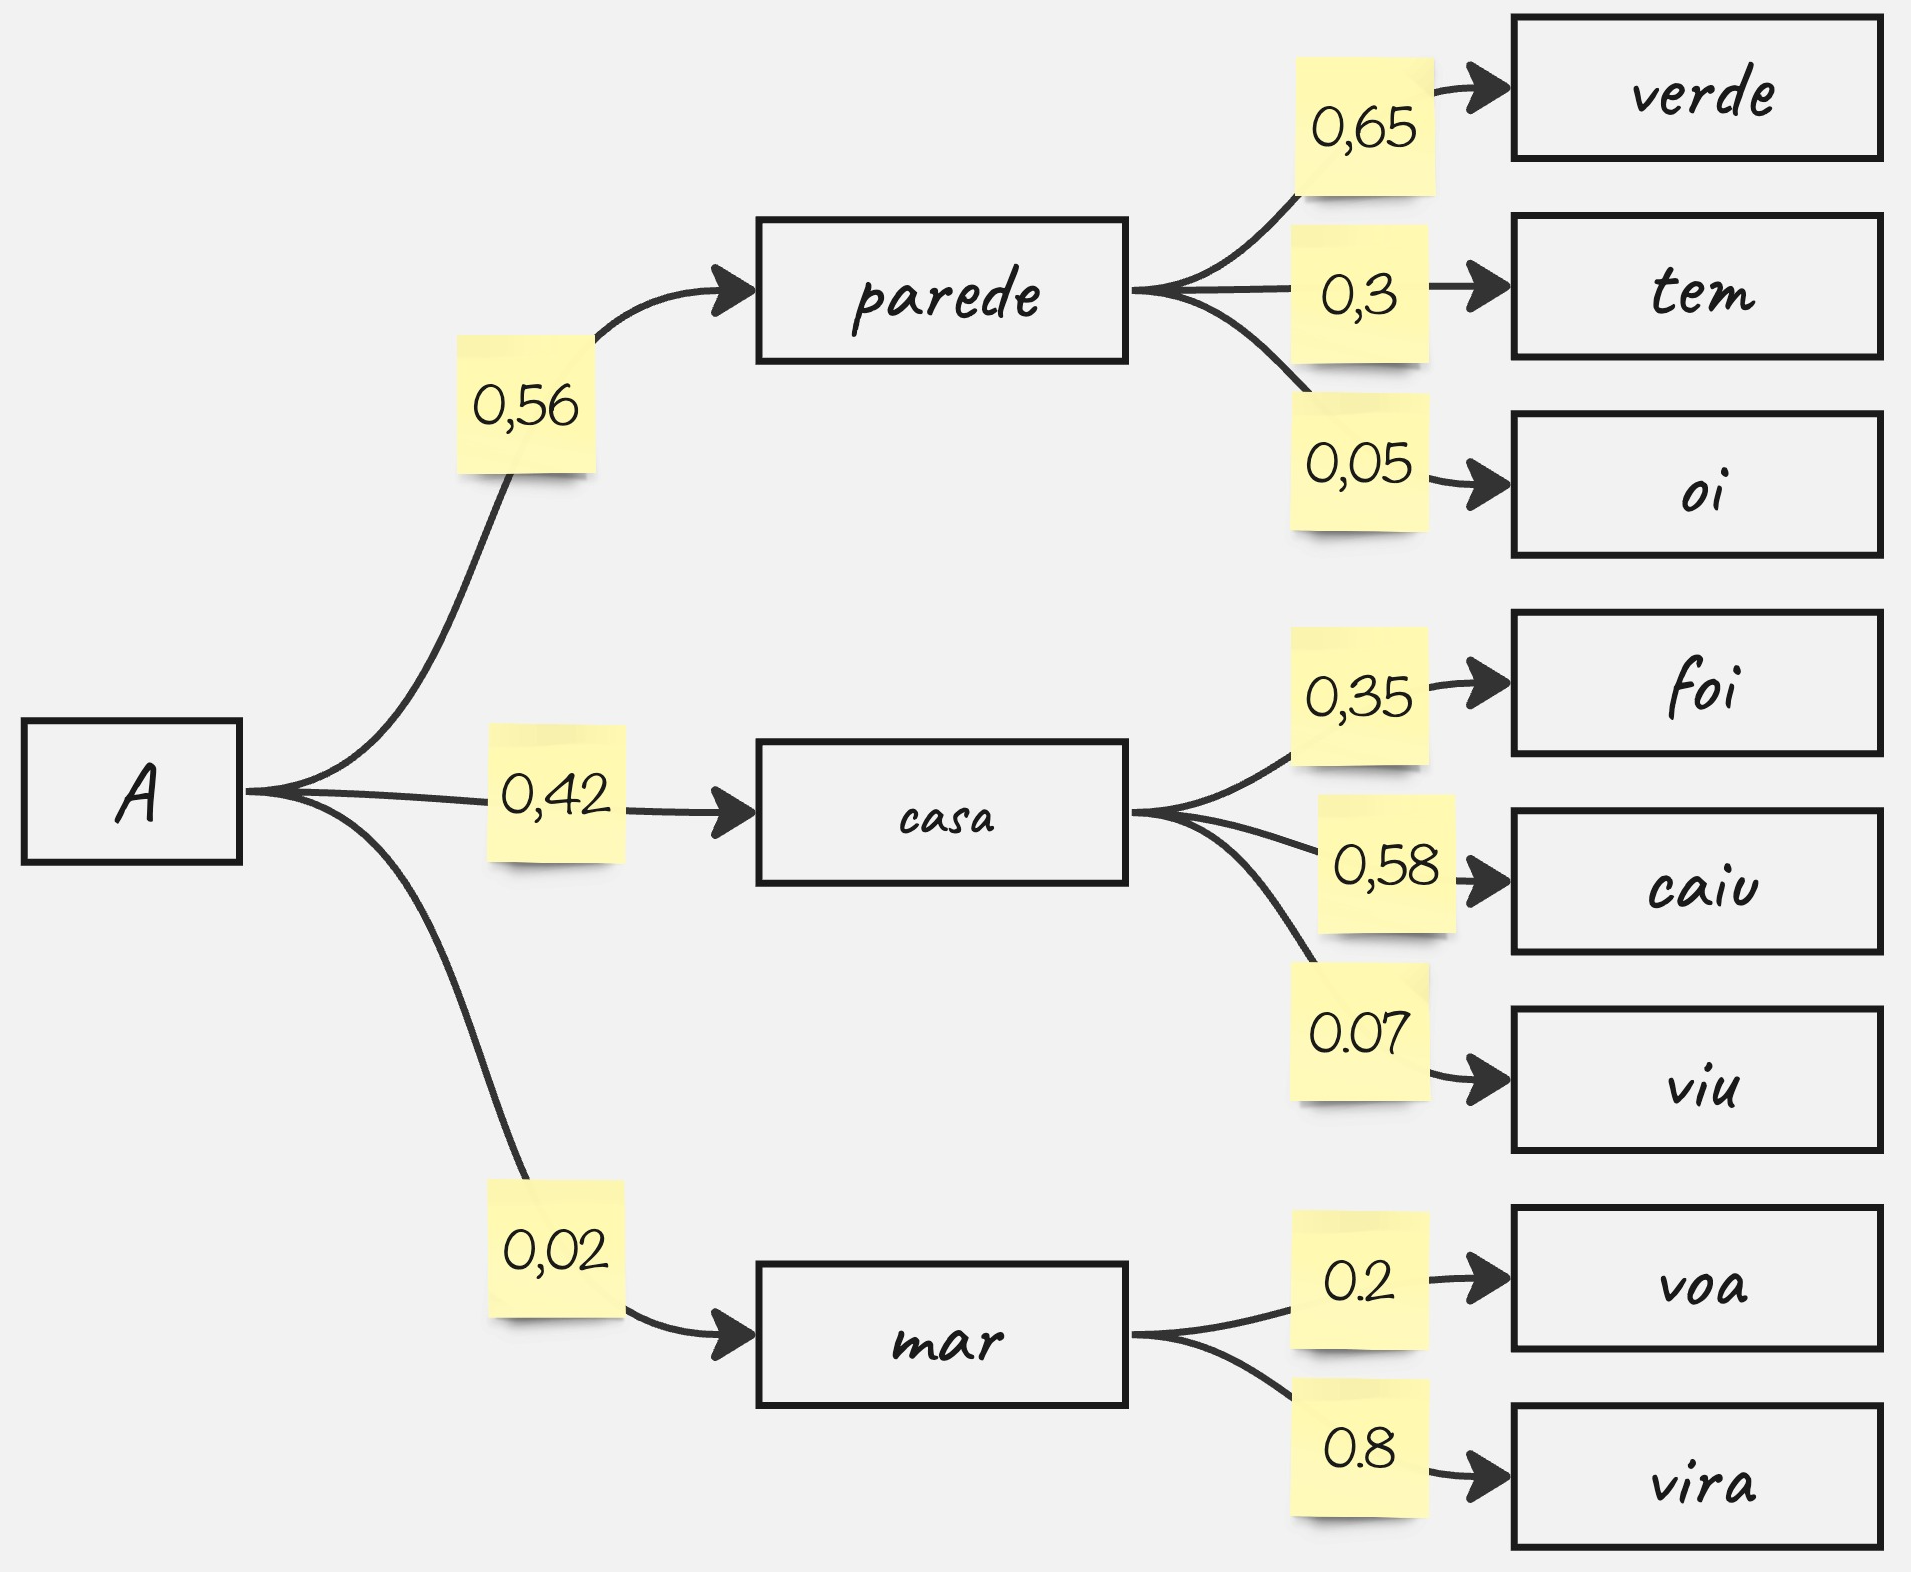

## 1. Classificação de textos com BERTimbau

In [23]:
import os
import sys
import torch
import numpy as np
import datasets.config

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -------------------------------------------------------------------
# Correções de ambiente
# -------------------------------------------------------------------

os.environ["WANDB_DISABLED"] = "true"

# Evita erro do torchvision no Colab em datasets de texto
datasets.config.TORCHVISION_AVAILABLE = False

for module_name in list(sys.modules.keys()):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

# -------------------------------------------------------------------
# Configurações gerais
# -------------------------------------------------------------------

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"  # BERTimbau
BATCH_SIZE = 8
NUM_EPOCHS = 3
MAX_LEN = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# -------------------------------------------------------------------
# Dados de exemplo
# -------------------------------------------------------------------

data = {
    "train": [
        {"text": "O BERT é ótimo para NLP em português!", "label": 0},
        {"text": "Hoje vai chover à tarde.", "label": 1},
        {"text": "Python é uma excelente linguagem.", "label": 2},
    ],
    "validation": [
        {"text": "A previsão do tempo é de sol amanhã.", "label": 1},
        {"text": "Estou aprendendo Machine Learning.", "label": 2},
    ],
}

train_dataset = Dataset.from_list(data["train"])
validation_dataset = Dataset.from_list(data["validation"])

dataset = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset
})

# -------------------------------------------------------------------
# Tokenização
# -------------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Renomeia label para labels, como o Trainer espera
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Remove a coluna textual original
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Aplica formato torch separadamente
train_tokenized = tokenized_datasets["train"].with_format("torch")
validation_tokenized = tokenized_datasets["validation"].with_format("torch")

# -------------------------------------------------------------------
# Modelo
# -------------------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

# -------------------------------------------------------------------
# Argumentos de treinamento
# -------------------------------------------------------------------
# Correção principal:
# evaluation_strategy foi substituído por eval_strategy nesta versão.

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# -------------------------------------------------------------------
# Métricas
# -------------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# -------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    compute_metrics=compute_metrics,
)

# -------------------------------------------------------------------
# Treinamento
# -------------------------------------------------------------------

trainer.train()

# -------------------------------------------------------------------
# Avaliação final
# -------------------------------------------------------------------

metrics = trainer.evaluate()
print("Métricas de avaliação:", metrics)

# -------------------------------------------------------------------
# Predição em novos textos
# -------------------------------------------------------------------

new_texts = [
    "O tempo está ensolarado.",
    "Aprender NLP é muito interessante."
]

new_encodings = tokenizer(
    new_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

new_encodings = {
    key: value.to(device)
    for key, value in new_encodings.items()
}

model.eval()

with torch.no_grad():
    outputs = model(**new_encodings)
    predictions = torch.argmax(outputs.logits, dim=1)

print(f"Predições: {predictions.cpu().numpy()}")

Usando dispositivo: cuda


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.932861,3,1.000000,1.000000,1.000000,1.000000


Métricas de avaliação: {'eval_loss': 0.932861328125, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0}
Predições: [1 0]


## 2. Usando NER em Spacy 3.0 com BERTimbau

Nesta etapa vamos usar o dataset **DL-2024** do Kaggle (`georgekurokijr/dl-2024`) como base única de textos.

O fluxo foi ajustado para:

1. carregar o arquivo tabular usando `latin-1`;
2. juntar as colunas `Título_Público` e `Descricao_pública` em uma única coluna textual;
3. identificar entidades nomeadas com spaCy;
4. treinar um modelo NER spaCy a partir das entidades identificadas automaticamente;
5. gerar embeddings com BERTimbau;
6. criar clusters de textos a partir desses embeddings.

> Observação: como o dataset não traz anotações manuais de entidades no formato NER, o treinamento do spaCy abaixo usa uma estratégia de *weak supervision*: primeiro o modelo `pt_core_news_lg` identifica entidades e, em seguida, essas entidades são usadas como exemplos de treino para um modelo spaCy específico deste domínio. Para um trabalho final mais rigoroso, o ideal é revisar/anotar manualmente parte das entidades antes do treinamento definitivo.


In [38]:
# Dependências para baixar o dataset, carregar dados, usar spaCy, BERTimbau e clusterização
!pip -q install kagglehub pandas numpy scikit-learn transformers accelerate spacy matplotlib
!python -m spacy download pt_core_news_lg -q
!pip -q install spacy-lookups-data


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 584.2 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [25]:
import os
import glob
import random
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import torch

from spacy.training import Example
from spacy.util import minibatch, compounding, filter_spans
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")

DATASET_SLUG = "georgekurokijr/dl-2024"
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

RANDOM_STATE = 42
MAX_LEN = 256
BATCH_SIZE = 8
MAX_TEXTS_FOR_NER_TRAINING = 600
NER_EPOCHS = 10
MIN_K = 2
MAX_K = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


In [26]:
# Baixar/localizar o dataset do Kaggle.
# Em notebooks do Kaggle, você também pode adaptar para usar diretamente /kaggle/input.
try:
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
except Exception as exc:
    raise RuntimeError(
        "Não foi possível baixar o dataset pelo kagglehub. "
        "No Colab, confirme se o ambiente tem internet e se a autenticação do Kaggle está configurada quando necessário."
    ) from exc

print("Dataset baixado/localizado em:", dataset_path)

all_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        all_files.append(os.path.join(root, file))

print("Arquivos encontrados:")
for file in all_files:
    print("-", file)


100%|██████████| 348k/348k [00:00<00:00, 942kB/s]

Extracting files...
Dataset baixado/localizado em: /root/.cache/kagglehub/datasets/georgekurokijr/dl-2024/versions/3
Arquivos encontrados:
- /root/.cache/kagglehub/datasets/georgekurokijr/dl-2024/versions/3/dadosTextosCientificos.tsv


In [27]:
def read_csv_latin1(file_path: str, sep=None) -> pd.DataFrame:
    """Carrega CSV/TSV em latin-1. Usa separador automático quando possível."""
    try:
        return pd.read_csv(file_path, encoding="latin-1", sep=sep, engine="python")
    except UnicodeDecodeError:
        print("Falha em latin-1. Tentando UTF-8 como fallback...")
        return pd.read_csv(file_path, encoding="utf-8", sep=sep, engine="python")


def load_first_supported_file(base_path: str) -> pd.DataFrame:
    """Carrega o primeiro arquivo tabular encontrado no dataset."""
    supported_extensions = (".csv", ".tsv", ".json", ".jsonl", ".xlsx", ".parquet")
    files = [
        file
        for file in glob.glob(os.path.join(base_path, "**", "*"), recursive=True)
        if os.path.isfile(file) and file.lower().endswith(supported_extensions)
    ]

    if not files:
        raise FileNotFoundError(
            "Nenhum arquivo tabular foi encontrado. "
            "Formatos suportados: CSV, TSV, JSON, JSONL, XLSX e Parquet."
        )

    file_path = files[0]
    print("Arquivo carregado:", file_path)

    lower = file_path.lower()
    if lower.endswith(".csv"):
        return read_csv_latin1(file_path, sep=None)
    if lower.endswith(".tsv"):
        return read_csv_latin1(file_path, sep="	")
    if lower.endswith(".jsonl"):
        return pd.read_json(file_path, lines=True)
    if lower.endswith(".json"):
        return pd.read_json(file_path)
    if lower.endswith(".xlsx"):
        return pd.read_excel(file_path)
    if lower.endswith(".parquet"):
        return pd.read_parquet(file_path)

    raise ValueError(f"Formato não suportado: {file_path}")


df = load_first_supported_file(dataset_path)

print("Dimensões do dataset:", df.shape)
print("Colunas:", list(df.columns))
display(df.head())


Arquivo carregado: /root/.cache/kagglehub/datasets/georgekurokijr/dl-2024/versions/3/dadosTextosCientificos.tsv
Dimensões do dataset: (2725, 2)
Colunas: ['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...


In [28]:
# Criar um dataset único de texto juntando Título_Público + Descricao_pública.
# Os nomes abaixo contemplam variações comuns de acento, maiúsculas/minúsculas e underscores.

def normalize_column_name(name: str) -> str:
    return (
        str(name)
        .strip()
        .lower()
        .replace("ã", "a")
        .replace("á", "a")
        .replace("à", "a")
        .replace("â", "a")
        .replace("é", "e")
        .replace("ê", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ô", "o")
        .replace("õ", "o")
        .replace("ú", "u")
        .replace("ç", "c")
        .replace(" ", "_")
        .replace("-", "_")
    )

normalized_columns = {normalize_column_name(col): col for col in df.columns}

TITLE_CANDIDATES = [
    "titulo_publico", "titulo", "title", "nome_publico", "projeto", "nome_projeto"
]

DESCRIPTION_CANDIDATES = [
    "descricao_publica", "descrição_publica", "descricao", "description", "resumo", "abstract"
]

TITLE_COLUMN = next((normalized_columns[c] for c in TITLE_CANDIDATES if c in normalized_columns), None)
DESCRIPTION_COLUMN = next((normalized_columns[c] for c in DESCRIPTION_CANDIDATES if c in normalized_columns), None)

# Fallback: se não encontrar pelos nomes, usa as duas primeiras colunas textuais.
if TITLE_COLUMN is None or DESCRIPTION_COLUMN is None:
    object_columns = [col for col in df.columns if df[col].dtype == "object"]
    if len(object_columns) < 2:
        raise ValueError("Não encontrei duas colunas textuais para montar o dataset único.")
    TITLE_COLUMN = TITLE_COLUMN or object_columns[0]
    DESCRIPTION_COLUMN = DESCRIPTION_COLUMN or object_columns[1]

print("Coluna de título:", TITLE_COLUMN)
print("Coluna de descrição:", DESCRIPTION_COLUMN)

df_textos = df[[TITLE_COLUMN, DESCRIPTION_COLUMN]].copy()
df_textos = df_textos.rename(columns={TITLE_COLUMN: "titulo", DESCRIPTION_COLUMN: "descricao"})

df_textos["titulo"] = df_textos["titulo"].fillna("").astype(str).str.strip()
df_textos["descricao"] = df_textos["descricao"].fillna("").astype(str).str.strip()

df_textos["texto"] = (
    df_textos["titulo"]
    + ". "
    + df_textos["descricao"]
)

# Limpeza básica
df_textos["texto"] = (
    df_textos["texto"]
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(". .", ".", regex=False)
    .str.strip()
)

df_textos = df_textos[df_textos["texto"].str.len() > 10].reset_index(drop=True)

print("Total de textos no dataset único:", len(df_textos))
display(df_textos[["titulo", "descricao", "texto"]].head())


Coluna de título: Título_Público
Coluna de descrição: Descricao_pública
Total de textos no dataset único: 2721


,titulo,descricao,texto
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja. ...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...


In [29]:
from spacy.training import offsets_to_biluo_tags

In [31]:
nlp = spacy.load("pt_core_news_lg")

In [32]:
# Adiciona o NER ao pipeline do spaCy (caso ainda não esteja)
if "ner" not in nlp.pipe_names:
    ner = nlp.create_pipe("ner")
    nlp.add_pipe(ner, last=True)
else:
    ner = nlp.get_pipe("ner")

In [33]:
TRAINING_DATA = [
    ("A impressora Ultimaker S5 produziu suportes em PLA.", {"entities": [(13, 25, "MACHINE"), (47, 50, "MATERIAL")]}),
    ("O filamento ABS apresentou empenamento durante a impressão FDM.", {"entities": [(12, 15, "MATERIAL"), (59, 62, "PROCESS")]}),
    ("A peça foi fabricada em Nylon PA12 por sinterização seletiva a laser.", {"entities": [(24, 34, "MATERIAL"), (39, 68, "PROCESS")]}),
    ("O laboratório ajustou o preenchimento para 40% no Cura.", {"entities": [(43, 46, "PARAMETER"), (50, 54, "SOFTWARE")]}),
    ("A resina Tough Resin foi curada na Form Wash.", {"entities": [(9, 20, "MATERIAL"), (35, 44, "MACHINE")]}),
    ("O bico de 0,4 mm melhorou o acabamento da peça.", {"entities": [(10, 16, "PARAMETER")]}),
    ("A EOS M290 imprimiu o suporte em aço inoxidável 316L.", {"entities": [(2, 10, "MACHINE"), (32, 52, "MATERIAL")]}),
    ("O processo SLA gerou alta precisão dimensional no protótipo.", {"entities": [(11, 14, "PROCESS")]}),
    ("A velocidade de impressão foi reduzida para 45 mm/s.", {"entities": [(43, 50, "PARAMETER")]}),
    ("O engenheiro modelou a peça no Fusion 360 antes do fatiamento.", {"entities": [(30, 40, "SOFTWARE")]}),

    ("A tecnologia SLS foi usada para produzir engrenagens em PA11.", {"entities": [(13, 16, "PROCESS"), (57, 61, "MATERIAL")]}),
    ("O lote de TPU flexível exigiu temperatura de 230 °C.", {"entities": [(10, 22, "MATERIAL"), (47, 53, "PARAMETER")]}),
    ("A Prusa i3 MK3S fabricou um gabarito de montagem.", {"entities": [(2, 15, "MACHINE")]}),
    ("O operador configurou altura de camada de 0,2 mm no PrusaSlicer.", {"entities": [(42, 48, "PARAMETER"), (52, 63, "SOFTWARE")]}),
    ("A manufatura por DMLS permitiu criar canais internos complexos.", {"entities": [(17, 21, "PROCESS")]}),
    ("O pó de Ti6Al4V foi reaproveitado após peneiramento.", {"entities": [(8, 15, "MATERIAL")]}),
    ("A impressora Form 3 executou a peça com resina biocompatível.", {"entities": [(13, 19, "MACHINE"), (40, 61, "MATERIAL")]}),
    ("A mesa aquecida foi mantida em 80 °C para reduzir warping.", {"entities": [(32, 37, "PARAMETER")]}),
    ("O Magics preparou os suportes para impressão metálica.", {"entities": [(2, 8, "SOFTWARE")]}),
    ("O processo Binder Jetting foi escolhido para o molde de areia.", {"entities": [(11, 25, "PROCESS")]}),

    ("A Markforged X7 reforçou a peça com fibra de carbono contínua.", {"entities": [(2, 15, "MACHINE"), (36, 63, "MATERIAL")]}),
    ("O PLA reciclado foi testado com 20% de preenchimento.", {"entities": [(2, 15, "MATERIAL"), (32, 35, "PARAMETER")]}),
    ("A técnica PolyJet permitiu imprimir múltiplas cores.", {"entities": [(10, 17, "PROCESS")]}),
    ("O Simplify3D gerou o G-code para a impressora cartesiana.", {"entities": [(2, 12, "SOFTWARE"), (21, 27, "FILE_FORMAT")]}),
    ("A temperatura do extrusor ficou em 215 °C durante o ensaio.", {"entities": [(35, 41, "PARAMETER")]}),
    ("A Raise3D Pro2 fabricou carcaças em PETG.", {"entities": [(2, 14, "MACHINE"), (37, 41, "MATERIAL")]}),
    ("O processo FFF foi usado em uma célula de prototipagem rápida.", {"entities": [(11, 14, "PROCESS")]}),
    ("A amostra de PEEK exigiu câmara aquecida.", {"entities": [(13, 17, "MATERIAL")]}),
    ("O fatiador Bambu Studio calculou 6 horas de impressão.", {"entities": [(10, 22, "SOFTWARE"), (32, 39, "PARAMETER")]}),
    ("A Bambu Lab X1 Carbon imprimiu uma peça em ASA.", {"entities": [(2, 21, "MACHINE"), (44, 47, "MATERIAL")]}),

    ("A densidade de energia foi ajustada para 55 J/mm³ no LPBF.", {"entities": [(43, 51, "PARAMETER"), (55, 59, "PROCESS")]}),
    ("O pó de Inconel 718 foi processado na Renishaw AM400.", {"entities": [(8, 19, "MATERIAL"), (38, 52, "MACHINE")]}),
    ("A peça em resina Standard apresentou boa definição de detalhes.", {"entities": [(10, 25, "MATERIAL")]}),
    ("O Meshmixer corrigiu a malha STL antes da impressão.", {"entities": [(2, 11, "SOFTWARE"), (29, 32, "FILE_FORMAT")]}),
    ("A estratégia de suporte em árvore reduziu o consumo de material.", {"entities": [(16, 33, "FEATURE")]}),
    ("O processo Material Jetting foi validado para protótipos visuais.", {"entities": [(11, 27, "PROCESS")]}),
    ("A Creality Ender 3 V2 recebeu um bico de 0,6 mm.", {"entities": [(2, 22, "MACHINE"), (43, 49, "PARAMETER")]}),
    ("O filamento HIPS foi usado como material solúvel de suporte.", {"entities": [(12, 16, "MATERIAL")]}),
    ("A taxa de fluxo foi calibrada para 98%.", {"entities": [(37, 40, "PARAMETER")]}),
    ("O Netfabb otimizou a orientação da peça na bandeja.", {"entities": [(2, 9, "SOFTWARE")]}),

    ("A HP Multi Jet Fusion produziu conectores em PA12.", {"entities": [(2, 21, "PROCESS"), (44, 48, "MATERIAL")]}),
    ("O equipamento HP Jet Fusion 5200 fabricou componentes funcionais.", {"entities": [(14, 32, "MACHINE")]}),
    ("A camada de 50 micra aumentou a resolução no processo SLA.", {"entities": [(12, 20, "PARAMETER"), (55, 58, "PROCESS")]}),
    ("A liga AlSi10Mg foi usada em suportes aeroespaciais.", {"entities": [(7, 15, "MATERIAL")]}),
    ("O GrabCAD Print enviou o arquivo para a Stratasys F370.", {"entities": [(2, 15, "SOFTWARE"), (38, 52, "MACHINE")]}),
    ("O processo LOM lamina folhas para formar geometrias tridimensionais.", {"entities": [(11, 14, "PROCESS")]}),
    ("A resina Dental SG foi aplicada em guias cirúrgicos.", {"entities": [(9, 18, "MATERIAL")]}),
    ("O parâmetro retração foi definido em 1,2 mm.", {"entities": [(12, 20, "PARAMETER"), (36, 42, "PARAMETER")]}),
    ("A Zortrax M200 imprimiu caixas eletrônicas em ABS.", {"entities": [(2, 14, "MACHINE"), (47, 50, "MATERIAL")]}),
    ("O Ultimaker Cura estimou 32 gramas de material.", {"entities": [(2, 16, "SOFTWARE"), (25, 34, "PARAMETER")]}),

    ("A manufatura WAAM depositou aço carbono em camadas.", {"entities": [(13, 17, "PROCESS"), (28, 39, "MATERIAL")]}),
    ("A velocidade do laser foi configurada em 900 mm/s.", {"entities": [(40, 48, "PARAMETER")]}),
    ("A máquina Concept Laser M2 produziu insertos com refrigeração interna.", {"entities": [(10, 26, "MACHINE")]}),
    ("O filamento PC apresentou alta resistência térmica.", {"entities": [(12, 14, "MATERIAL")]}),
    ("O arquivo 3MF preservou informações de material e cor.", {"entities": [(10, 13, "FILE_FORMAT")]}),
    ("A técnica EBM foi escolhida para implantes de titânio.", {"entities": [(10, 13, "PROCESS"), (46, 53, "MATERIAL")]}),
    ("O Artec Studio preparou a digitalização para impressão 3D.", {"entities": [(2, 14, "SOFTWARE")]}),
    ("A espessura de parede foi ajustada para 1,6 mm.", {"entities": [(41, 47, "PARAMETER")]}),
    ("A Anycubic Photon Mono X curou camadas de resina transparente.", {"entities": [(2, 24, "MACHINE"), (42, 62, "MATERIAL")]}),
    ("O processo Vat Photopolymerization utiliza luz para solidificar resina.", {"entities": [(11, 35, "PROCESS"), (64, 70, "MATERIAL")]}),

    ("O filamento PETG-CF reduziu a deformação da peça.", {"entities": [(12, 19, "MATERIAL")]}),
    ("O suporte solúvel em PVA foi removido após a impressão.", {"entities": [(21, 24, "MATERIAL")]}),
    ("A orientação a 45 graus diminuiu a necessidade de suportes.", {"entities": [(14, 23, "PARAMETER")]}),
    ("O Repetier-Host controlou a impressão durante o teste.", {"entities": [(2, 15, "SOFTWARE")]}),
    ("A impressora Sinterit Lisa processou pó de TPU.", {"entities": [(13, 26, "MACHINE"), (42, 45, "MATERIAL")]}),
    ("O processo Directed Energy Deposition reparou a borda da turbina.", {"entities": [(11, 37, "PROCESS")]}),
    ("A liga CoCr foi usada em uma prótese odontológica.", {"entities": [(7, 11, "MATERIAL")]}),
    ("O tempo de exposição foi definido em 8 segundos por camada.", {"entities": [(37, 47, "PARAMETER")]}),
    ("O IdeaMaker aplicou preenchimento gyroid no suporte.", {"entities": [(2, 11, "SOFTWARE"), (20, 41, "FEATURE")]}),
    ("A resina Castable Wax facilitou a fundição de joias.", {"entities": [(9, 21, "MATERIAL")]}),

    ("A Artillery Sidewinder X2 imprimiu um protótipo em PLA+.", {"entities": [(2, 25, "MACHINE"), (54, 58, "MATERIAL")]}),
    ("O processo Cold Spray depositou partículas metálicas sem fusão completa.", {"entities": [(11, 21, "PROCESS")]}),
    ("A altura de camada de 0,12 mm melhorou a qualidade superficial.", {"entities": [(21, 28, "PARAMETER")]}),
    ("O software Lychee Slicer preparou suportes para impressão em resina.", {"entities": [(11, 24, "SOFTWARE"), (62, 68, "MATERIAL")]}),
    ("A cerâmica técnica foi impressa por extrusão de pasta.", {"entities": [(2, 18, "MATERIAL"), (37, 54, "PROCESS")]}),
    ("A velocidade do ventilador foi limitada a 60%.", {"entities": [(43, 46, "PARAMETER")]}),
    ("A impressora Delta WASP 2040 produziu vasos com argila.", {"entities": [(13, 28, "MACHINE"), (50, 56, "MATERIAL")]}),
    ("O processo MJF reduziu o prazo de fabricação dos encaixes.", {"entities": [(11, 14, "PROCESS")]}),
    ("O filamento Nylon CF apresentou boa rigidez.", {"entities": [(12, 20, "MATERIAL")]}),
    ("O suporte foi exportado em formato OBJ.", {"entities": [(35, 38, "FILE_FORMAT")]}),

    ("A Ultimaker S3 foi calibrada antes da impressão em CPE.", {"entities": [(2, 14, "MACHINE"), (52, 55, "MATERIAL")]}),
    ("O parâmetro brim foi ativado para melhorar a adesão.", {"entities": [(12, 16, "PARAMETER")]}),
    ("A impressão em L-PBF exigiu atmosfera de argônio.", {"entities": [(15, 20, "PROCESS"), (42, 49, "MATERIAL")]}),
    ("O SolidWorks gerou o modelo CAD para manufatura aditiva.", {"entities": [(2, 12, "SOFTWARE"), (28, 31, "FILE_FORMAT")]}),
    ("A resina Flexible 80A foi usada em vedantes.", {"entities": [(9, 21, "MATERIAL")]}),
    ("A temperatura da mesa foi reduzida para 65 °C.", {"entities": [(41, 46, "PARAMETER")]}),
    ("A Sindoh 3DWOX 1 fabricou peças educacionais.", {"entities": [(2, 17, "MACHINE")]}),
    ("O processo Powder Bed Fusion consolida material em leito de pó.", {"entities": [(11, 28, "PROCESS")]}),
    ("O filamento Wood PLA gerou acabamento semelhante à madeira.", {"entities": [(12, 20, "MATERIAL")]}),
    ("O parâmetro infill foi configurado com padrão honeycomb.", {"entities": [(12, 18, "PARAMETER"), (46, 55, "FEATURE")]}),

    ("O software OrcaSlicer gerou perfis para a Bambu Lab P1P.", {"entities": [(11, 21, "SOFTWARE"), (42, 55, "MACHINE")]}),
    ("A resina High Temp suportou ensaios térmicos.", {"entities": [(9, 18, "MATERIAL")]}),
    ("O processo Robocasting fabricou estruturas cerâmicas porosas.", {"entities": [(11, 22, "PROCESS")]}),
    ("O diâmetro do filamento foi medido em 1,75 mm.", {"entities": [(40, 47, "PARAMETER")]}),
    ("A FlashForge Creator Pro imprimiu suportes em PLA.", {"entities": [(2, 24, "MACHINE"), (46, 49, "MATERIAL")]}),
    ("O filamento metal filled PLA simulou acabamento metálico.", {"entities": [(12, 28, "MATERIAL")]}),
    ("O Slic3r gerou paredes externas com duas linhas.", {"entities": [(2, 8, "SOFTWARE"), (36, 47, "PARAMETER")]}),
    ("A estratégia adaptive layers reduziu o tempo de fabricação.", {"entities": [(13, 28, "FEATURE")]}),
    ("O processo Sheet Lamination foi usado para modelos conceituais.", {"entities": [(11, 27, "PROCESS")]}),
    ("A resina BioMed Clear foi esterilizada após a impressão.", {"entities": [(9, 21, "MATERIAL")]}),
]

In [35]:
import random
from spacy.util import minibatch, compounding
from spacy.training import Example

In [34]:
# Add new labels to the NER
for _, annotations in TRAINING_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

In [40]:
import random
import spacy

from spacy.training import Example
from spacy.util import minibatch, compounding
from spacy.training.iob_utils import offsets_to_biluo_tags

# -------------------------------------------------------------------
# Criar um pipeline spaCy limpo para português
# -------------------------------------------------------------------
# Evita erro com vetores estáticos/CuPy do pt_core_news_lg.
# Para treinar NER customizado com poucos exemplos, este caminho é mais estável.

nlp = spacy.blank("pt")

# Adiciona componente NER
ner = nlp.add_pipe("ner")

# -------------------------------------------------------------------
# Adicionar labels ao NER
# -------------------------------------------------------------------

for text, annotations in TRAINING_DATA:
    for start, end, label in annotations.get("entities", []):
        ner.add_label(label)

print("Labels cadastrados no NER:")
print(ner.labels)

# -------------------------------------------------------------------
# Validar alinhamento das entidades
# -------------------------------------------------------------------

def is_valid_example(nlp, text, annotations):
    doc = nlp.make_doc(text)
    entities = annotations.get("entities", [])

    try:
        tags = offsets_to_biluo_tags(doc, entities)
    except Exception as e:
        print(f"Erro ao validar exemplo: {text}")
        print(e)
        return False

    # "-" indica desalinhamento entre offset e tokenização do spaCy
    if "-" in tags:
        print(f"Entidade desalinhada, ignorando: {text}")
        print("Entidades:", entities)
        print("Tokens:", [
            (token.text, token.idx, token.idx + len(token.text))
            for token in doc
        ])
        return False

    return True


TRAINING_DATA_VALID = [
    (text, annotations)
    for text, annotations in TRAINING_DATA
    if is_valid_example(nlp, text, annotations)
]

print(f"Total original: {len(TRAINING_DATA)}")
print(f"Total válido: {len(TRAINING_DATA_VALID)}")

if len(TRAINING_DATA_VALID) == 0:
    raise ValueError("Nenhum exemplo válido encontrado. Verifique os offsets das entidades.")

# -------------------------------------------------------------------
# Converter dados válidos para objetos Example
# -------------------------------------------------------------------

def make_examples(nlp, training_data):
    examples = []

    for text, annotations in training_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)
        examples.append(example)

    return examples


initial_examples = make_examples(nlp, TRAINING_DATA_VALID)

# -------------------------------------------------------------------
# Inicializar o pipeline
# -------------------------------------------------------------------

optimizer = nlp.initialize(lambda: initial_examples)

# -------------------------------------------------------------------
# Treinamento
# -------------------------------------------------------------------

N_ITER = 100

for iteration in range(N_ITER):
    random.shuffle(TRAINING_DATA_VALID)
    losses = {}

    batches = minibatch(
        TRAINING_DATA_VALID,
        size=compounding(4.0, 32.0, 1.001)
    )

    for batch in batches:
        examples = make_examples(nlp, batch)

        nlp.update(
            examples,
            sgd=optimizer,
            drop=0.35,
            losses=losses
        )

    print(f"Iteration {iteration} Losses: {losses}")

    if losses.get("ner", 0) < 0.01:
        print(f"Early stopping at iteration {iteration}")
        break

# -------------------------------------------------------------------
# Salvar modelo treinado
# -------------------------------------------------------------------

nlp.to_disk("custom_ner_model")

print("Modelo salvo em: custom_ner_model")

Labels cadastrados no NER:
('FEATURE', 'FILE_FORMAT', 'MACHINE', 'MATERIAL', 'PARAMETER', 'PROCESS', 'SOFTWARE')
Entidade desalinhada, ignorando: A EOS M290 imprimiu o suporte em aço inoxidável 316L.
Entidades: [(2, 10, 'MACHINE'), (32, 52, 'MATERIAL')]
Tokens: [('A', 0, 1), ('EOS', 2, 5), ('M290', 6, 10), ('imprimiu', 11, 19), ('o', 20, 21), ('suporte', 22, 29), ('em', 30, 32), ('aço', 33, 36), ('inoxidável', 37, 47), ('316L.', 48, 53)]
Entidade desalinhada, ignorando: A velocidade de impressão foi reduzida para 45 mm/s.
Entidades: [(43, 50, 'PARAMETER')]
Tokens: [('A', 0, 1), ('velocidade', 2, 12), ('de', 13, 15), ('impressão', 16, 25), ('foi', 26, 29), ('reduzida', 30, 38), ('para', 39, 43), ('45', 44, 46), ('mm', 47, 49), ('/', 49, 50), ('s.', 50, 52)]
Entidade desalinhada, ignorando: O engenheiro modelou a peça no Fusion 360 antes do fatiamento.
Entidades: [(30, 40, 'SOFTWARE')]
Tokens: [('O', 0, 1), ('engenheiro', 2, 12), ('modelou', 13, 20), ('a', 21, 22), ('peça', 23, 27), ('no

In [41]:
# Testar o modelo NER treinado no próprio domínio.

nlp_ner_trained = spacy.load("custom_ner_model")

for text in df_textos["texto"].head(5):
    doc = nlp_ner_trained(text)
    print("TEXTO:", text[:500])
    print("ENTIDADES:", [(ent.text, ent.label_) for ent in doc.ents])
    print("-" * 100)


TEXTO: Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contribui para os Objetivos de Desenvolvimento Sustentável (ODS) estabelecidos pela Organização das Nações Unidas (ONU) especialmente no âmbito do Objetivo 12 (Assegurar pad
ENTIDADES: [('Açúcar', 'MATERIAL'), ('Brasil,', 'MATERIAL'), ('Objetivos', 'FILE_FORMAT'), ('Desenvolvimento Sustentável (', 'MATERIAL'), ('ODS', 'FILE_FORMAT'), ('Organização', 'PROCESS'), ('Nações Unidas (', 'PROCESS'), ('ONU', 'FILE_FORMAT'), ('Objetivo 12 (Assegurar', 'MATERIAL'), ('Diante', 'PROCESS')]
----------------------------------------------------------------------------------------------------
TEXTO: Desenvolver uma linha de farofas com castanhas brasileiras e adição de prot

In [42]:
# Gerar embeddings dos textos com BERTimbau.
# Usamos mean pooling sobre os tokens, respeitando a attention_mask.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bertimbau = AutoModel.from_pretrained(MODEL_NAME).to(device)
bertimbau.eval()


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def generate_embeddings(texts, batch_size=BATCH_SIZE):
    embeddings = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}

        with torch.no_grad():
            outputs = bertimbau(**encoded)
            batch_embeddings = mean_pooling(outputs.last_hidden_state, encoded["attention_mask"])

        embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)

embeddings = generate_embeddings(df_textos["texto"].tolist())
print("Formato dos embeddings:", embeddings.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Formato dos embeddings: (2721, 768)


,k,silhouette
0,2,0.086307
1,3,0.058721
2,4,0.028747
3,5,0.031694
4,6,0.036831
5,7,0.021590
6,8,0.023766
7,9,0.014833
8,10,0.027577


Melhor k pelo silhouette: 2


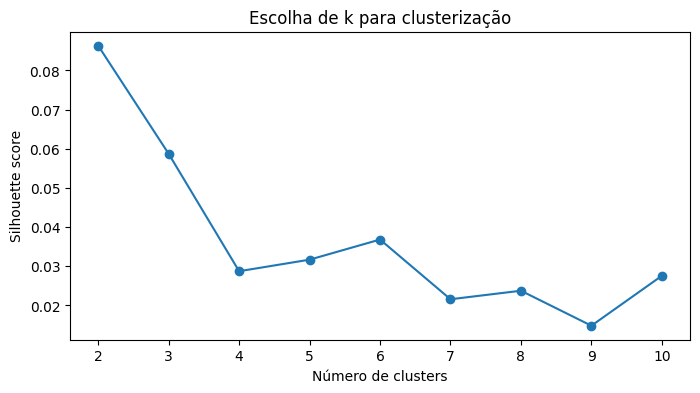

In [43]:
# Escolher uma quantidade de clusters usando silhouette score.
# O limite máximo é ajustado automaticamente para bases pequenas.

max_k_adjusted = min(MAX_K, len(df_textos) - 1)

if max_k_adjusted < MIN_K:
    raise ValueError("Não há textos suficientes para clusterização.")

silhouette_results = []
for k in range(MIN_K, max_k_adjusted + 1):
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels_tmp = kmeans_tmp.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels_tmp)
    silhouette_results.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

best_k = int(silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Melhor k pelo silhouette:", best_k)

plt.figure(figsize=(8, 4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Escolha de k para clusterização")
plt.show()


In [44]:
# Treinar o KMeans final e atribuir o cluster a cada texto.

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
df_textos["cluster"] = kmeans.fit_predict(embeddings)

print("Quantidade de textos por cluster:")
display(df_textos["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="quantidade"))

display(df_textos[["cluster", "titulo", "descricao", "texto"]].head(20))


Quantidade de textos por cluster:


,cluster,quantidade
0,0,1083
1,1,1638


,cluster,titulo,descricao,texto
0,1,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...
1,1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...
2,1,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...
3,1,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja. ...
4,1,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...
5,1,Desenvolvimento de Mistura Instantânea (Tipo C...,O Estado de Mato Grosso do Sul apresenta uma g...,Desenvolvimento de Mistura Instantânea (Tipo C...
6,1,Desenvolvimento de mistura instantânea a base ...,"O cacau é um fruto versátil, principalmente de...",Desenvolvimento de mistura instantânea a base ...
7,1,Desenvolvimento de molhos pesto de manjericão ...,Os pesquisadores na área da tecnologia de alim...,Desenvolvimento de molhos pesto de manjericão ...
8,1,Desenvolvimento de Shake instantâneo com frutos,A busca por alimentos saudáveis e funcionais t...,Desenvolvimento de Shake instantâneo com fruto...
9,1,Desenvolvimento de suplemento energético,Atualmente observa-se uma mudança no perfil do...,Desenvolvimento de suplemento energético. Atua...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [46]:
STOPWORDS_PT = [
    # artigos
    "a", "o", "as", "os", "um", "uma", "uns", "umas",

    # preposições e contrações
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "pelos", "pelas",
    "para", "pra", "com", "sem", "sob", "sobre",
    "entre", "até", "após", "antes", "desde",
    "contra", "perante",

    # conjunções
    "e", "ou", "mas", "porém", "contudo", "todavia",
    "porque", "pois", "que", "se", "quando", "enquanto",
    "como", "conforme", "embora", "caso",

    # pronomes
    "eu", "tu", "ele", "ela", "nós", "vós", "eles", "elas",
    "me", "te", "se", "nos", "vos",
    "meu", "minha", "meus", "minhas",
    "teu", "tua", "teus", "tuas",
    "seu", "sua", "seus", "suas",
    "nosso", "nossa", "nossos", "nossas",
    "este", "esta", "estes", "estas",
    "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",
    "isto", "isso", "aquilo",
    "quem", "qual", "quais", "cujo", "cuja", "cujos", "cujas",

    # verbos muito comuns
    "ser", "estar", "ter", "haver", "fazer", "ir", "vir",
    "foi", "foram", "era", "eram", "são", "é",
    "está", "estão", "estava", "estavam",
    "tem", "têm", "tinha", "tinham",
    "há", "houve", "havia",
    "faz", "fez", "fazer", "feito",
    "vai", "vão", "foi", "indo",
    "pode", "podem", "poder", "poderá", "poderão",
    "deve", "devem", "dever", "deverá", "deverão",

    # advérbios comuns
    "não", "sim", "também", "ainda", "já", "sempre", "nunca",
    "muito", "muita", "muitos", "muitas",
    "pouco", "pouca", "poucos", "poucas",
    "mais", "menos", "bem", "mal",
    "aqui", "ali", "lá", "onde", "agora", "depois",
    "antes", "hoje", "ontem", "amanhã",

    # termos genéricos que costumam poluir cluster
    "projeto", "projetos",
    "desenvolvimento", "desenvolver", "desenvolvido",
    "solução", "soluções",
    "sistema", "sistemas",
    "processo", "processos",
    "produto", "produtos",
    "tecnologia", "tecnologias",
    "uso", "utilização", "utilizar", "utilizado",
    "aplicação", "aplicações",
    "método", "métodos",
    "modelo", "modelos",
    "análise", "avaliação",
    "estudo", "pesquisa",
    "dados", "informações",
    "empresa", "empresas",
    "área", "áreas",
    "setor", "setores",
    "objetivo", "objetivos",
    "resultado", "resultados",
    "forma", "meio", "parte", "tipo", "nível"
]

In [47]:
# Identificar termos representativos por cluster usando TF-IDF.

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents="unicode"
)

tfidf_matrix = vectorizer.fit_transform(df_textos["texto"])
terms = np.array(vectorizer.get_feature_names_out())

cluster_terms = []

for cluster_id in sorted(df_textos["cluster"].unique()):
    cluster_indices = df_textos.index[df_textos["cluster"] == cluster_id].tolist()

    mean_tfidf = np.asarray(
        tfidf_matrix[cluster_indices].mean(axis=0)
    ).ravel()

    top_indices = mean_tfidf.argsort()[::-1][:15]
    top_terms = terms[top_indices]

    cluster_terms.append({
        "cluster": cluster_id,
        "termos_representativos": ", ".join(top_terms),
        "quantidade_textos": len(cluster_indices),
    })

cluster_terms_df = pd.DataFrame(cluster_terms)
display(cluster_terms_df)

,cluster,termos_representativos,quantidade_textos
0,0,"software, solucao, plataforma, monitoramento, ...",1083
1,1,"producao, ao, partir, aplicacao, controle, ene...",1638


#### VISÃO DE CLUSTER POR PCA

O PCA tenta projetar os embeddings em 2 dimensões preservando o máximo possível da variação global dos dados.

Na sua imagem PCA:

* Cluster 0 ficou mais à esquerda;
* Cluster 1 ficou mais à direita;
existe uma fronteira relativamente clara perto do eixo vertical;
há sobreposição, mas a separação geral é bem visível.

Isso sugere que o KMeans provavelmente encontrou uma divisão baseada em uma diferença global forte nos embeddings BERTimbau.

Em outras palavras: o PCA está mostrando que há uma tendência geral de separação entre os dois grupos.

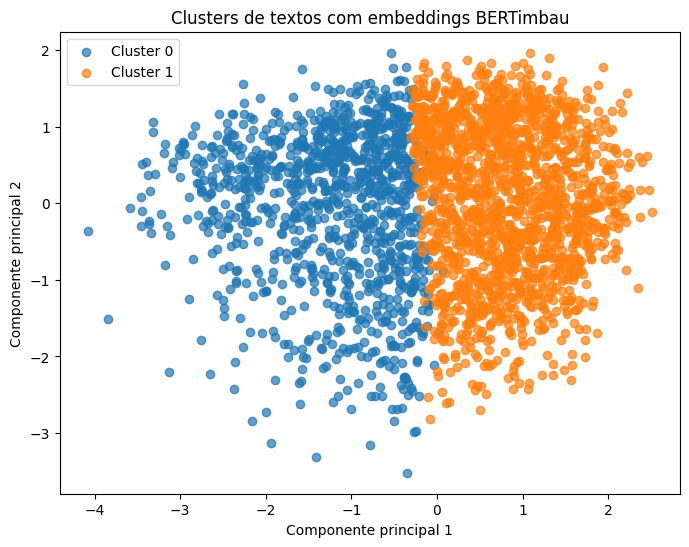

In [48]:
# Visualização 2D dos clusters com PCA.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
points_2d = pca.fit_transform(embeddings)

plot_df = pd.DataFrame({
    "x": points_2d[:, 0],
    "y": points_2d[:, 1],
    "cluster": df_textos["cluster"].astype(str),
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters de textos com embeddings BERTimbau")
plt.legend()
plt.show()


#### VISÃO DE CLUSTERS POR T-SNE

O t-SNE tenta preservar mais as relações locais: quais textos são parecidos com quais textos. Ele não tenta preservar bem as distâncias globais entre todos os pontos.

Na sua imagem t-SNE:

* aparecem “ilhas” e regiões curvas;
* Cluster 1 se espalha mais;
* há várias áreas onde azul e laranja se misturam;
* existe um pequeno agrupamento laranja isolado no topo.

Isso não significa necessariamente que o cluster está errado. Significa que, quando o algoritmo tenta preservar vizinhanças locais, ele encontra subgrupos internos dentro dos clusters.

Em outras palavras: o t-SNE está mostrando que dentro dos dois clusters existem subtemas ou zonas de transição.

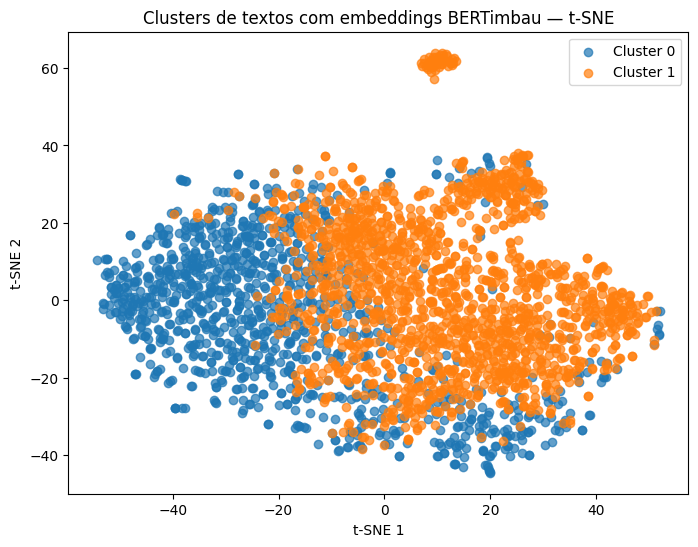

In [50]:
from sklearn.manifold import TSNE

# Visualização 2D dos clusters com t-SNE.
# t-SNE é melhor que PCA para visualização local de agrupamentos,
# mas pode variar um pouco entre execuções.

n_samples = embeddings.shape[0]

# O perplexity precisa ser menor que o número de amostras.
# Este ajuste evita erro em datasets pequenos.
perplexity = min(30, max(5, (n_samples - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

points_2d = tsne.fit_transform(embeddings)

plot_df = pd.DataFrame({
    "x": points_2d[:, 0],
    "y": points_2d[:, 1],
    "cluster": df_textos["cluster"].astype(str),
})

plt.figure(figsize=(8, 6))

for cluster_id in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(
        subset["x"],
        subset["y"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Clusters de textos com embeddings BERTimbau — t-SNE")
plt.legend()
plt.show()

## Como interpretar PCA + t-SNE

A leitura mais correta é:

`O PCA indica que há uma separação global razoável entre dois grandes grupos de textos.`

`O t-SNE indica que essa separação não é totalmente homogênea: existem subgrupos, zonas de mistura e possíveis temas intermediários.`

Isso é comum em textos, principalmente quando os embeddings vêm de BERTimbau. Um texto pode ser parecido com outro por tema, vocabulário, tipo de projeto, tecnologia, material, aplicação industrial etc. Então o t-SNE revela mais nuances.

Qual é melhor?

Para o seu objetivo:

* Use PCA para mostrar que os clusters fazem sentido de forma geral.

* Use t-SNE para investigar subgrupos e possíveis novos clusters.

In [51]:
for k in [2, 3, 4, 5, 6, 8, 10]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    print(k, score)

2 0.0863068
3 0.05872084
4 0.028747419
5 0.031694245
6 0.036831457
8 0.023765584
10 0.027576711


In [49]:
# Exportar resultados para análise posterior.
# latin-1 é usado aqui para manter compatibilidade com o carregamento solicitado.

output_dataset_path = "dl2024_textos_entidades_clusters.csv"
output_entities_path = "dl2024_entidades_nomeadas.csv"
output_cluster_terms_path = "dl2024_termos_clusters.csv"

df_textos.to_csv(output_dataset_path, index=False, encoding="latin-1")
df_entidades.to_csv(output_entities_path, index=False, encoding="latin-1")
cluster_terms_df.to_csv(output_cluster_terms_path, index=False, encoding="latin-1")

print("Arquivos exportados:")
print("-", output_dataset_path)
print("-", output_entities_path)
print("-", output_cluster_terms_path)


Arquivos exportados:
- dl2024_textos_entidades_clusters.csv
- dl2024_entidades_nomeadas.csv
- dl2024_termos_clusters.csv
